# SurgeSense: An Early Warning System for Patient Surges

# Business Understanding

## Background

The AIC Kijabe Hospital is located in Kiambu county, Kenya. It was founded in 1915 as a small outpatient clinic, with the goal of serving the local community. Today, it has transformed into one of the preeminent referral and teaching hospitals in Kenya. It is a Level VI National Tertiary Teaching and Referral hospital, with a 363 bed capacity, and over 900 staff members. It is the largest of five hospitals sponsored by the AIC networks across Kenya, and serves patients from across the country as well as neighbouring African nations. The hospital also offers specialized care, including 15 operating rooms, a 24-hour emergency casualty department, adult and paediatric intensive care units (ICUs), and dedicated oncology, dental and eye clinics.

## Problem Statement

The AIC Kijabe hospital's outpatient department (OPD) currently manages patient flow across approximately forty departments (General OPD, Casualty, Renal, Oncology, and others) without a structured way to anticipate periods of high patient volume. This can lead to under-staffing during surges and inefficient resource allocation during quieter periods. Additionally, no formal analysis exists on how patient volume and return differs across departments, which limits the hospital’s ability to plan follow up care capacity.

## Business Objectives
- To enable the hospital to anticipate periods of higher patient volume in advance, so that staffing and resources can be planned proactively rather than reactively.
- To understand patient return behavior (how long patients typically go before returning to the hospital) to support follow-up care planning.

## Specific Objectives  

- To build and evaluate regression models to forecast daily patient volume for the hospital’s high volume departments. 
- To identify which features most strongly predict patient volume per department. 

## Research Questions

- Can daily patient volume in the OPD be forecast accurately per department, in order to support staffing decisions and resource allocation?
- Which departments experience the highest volume variability, and therefore might be harder to plan for?

## Data Analysis Goals 

- To build a time series forecasting model to predict daily department-level patient arrival volume.
- To quantify the relationship between seasonal patterns and patient volume, including any lagged effects.
- To apply survival analysis to model time-to-return-visit, since discharge/exit data is not available in this dataset, return-visit interval is used as a signal for patient care continuity.

## Success Metrics for Prediction 

Success for this project will be defined against measurable targets.
- Mean Absolute Error (MAE) - The model will be evaluated using Mean Absolute Error, which measures the average absolute difference between the actual and predicted number of patients.
- Root Mean Squared Error (RMSE) - Root Mean Squared Error will be used to assess the magnitude of prediction errors while giving greater weight to larger errors.
- Mean Absolute Percentage Error (MAPE) - Mean Absolute Percentage Error will be used to measure prediction error as a percentage, providing a measure of the model's forecasting accuracy across different levels of patient demand.
- Coefficient of Determination (R²) - The coefficient of determination will be used to determine how well the model explains variations in daily patient volume.


# Data Preparation

In [1]:
# %pip install openpyxl
# %pip install XGBoost
# %pip install scikit-learn
# % pip install lifelines

In [2]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

In [3]:
# load the data
data = pd.read_excel("Opd_data.xlsx")
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
0,010575758,2024-06-01 00:00:00.000,Male,38 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
1,010575713,2024-06-01 00:00:00.000,Female,29 Yr(s),NaN,NaN
2,010569291,2024-06-01 00:04:38.083,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,010575732,2024-06-01 00:04:42.460,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,010575731,2024-06-01 00:10:16.037,Female,2 Yr(s),ADMISSION,Admission


In [4]:
# Basic exploratory
data.shape
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306306 entries, 0 to 306305
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PatientNumber       306306 non-null  object        
 1   RegistrationDate    306306 non-null  datetime64[ns]
 2   Gender              306291 non-null  object        
 3   Age                 305735 non-null  object        
 4   QueuedTo            299528 non-null  object        
 5   ConsultDescription  299920 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 14.0+ MB
None


## Data Cleaning

In [5]:
# Check for missing values
data.isnull().sum()

PatientNumber            0
RegistrationDate         0
Gender                  15
Age                    571
QueuedTo              6778
ConsultDescription    6386
dtype: int64

In [6]:
# check for duplicates
data.duplicated().sum()

355

In [7]:
# Drop the duplicates
data= data.drop_duplicates()

In [8]:
# Recheck for duplicates
data.duplicated().sum()

0

In [9]:
# Drop gender null values
data = data[data['Gender'].notna()]

In [10]:
# Standardize casing
data['Gender'] = data['Gender'].str.strip().str.upper()

## Age In Years

In [11]:
# extract the number and the unit separately
data['AgeNum'] = data['Age'].str.extract(r'(\d+)').astype(float)
# the numeric part, 38
data['AgeUnit'] = data['Age'].str.extract(r'\d+\s*(\D+)')[0].str.strip()  
# the unit part, "Yr(s)"

# convert based on unit: years stay the same, months divide by 12, weeks divide by 52, days divide by 365
conditions = [
    data['AgeUnit'] == 'Yr(s)',
    data['AgeUnit'] == 'Mth(s)',
    data['AgeUnit'] == 'Week(s)',
    data['AgeUnit'] == 'Days(s)'
]
choices = [
    data['AgeNum'],
    data['AgeNum'] / 12,
    data['AgeNum'] / 52,
    data['AgeNum'] / 365
]
data['AgeYears'] = np.select(conditions, choices, default=np.nan)

# round to 2 decimal places
data['AgeYears'] = data['AgeYears'].round(2)  

# only interested in age years
data = data.drop(columns=['AgeNum', 'AgeUnit'])


In [12]:
# Turning all impossible ages (>100)into NAN
data.loc[data['AgeYears'] > 100, 'AgeYears'] = np.nan

In [13]:
# calculate the mean age from all remaining valid values (this naturally excludes 
# both the >100 values we just nulled and any age that was already missing)
mean_age = round(data['AgeYears'].mean(), 2)
print(round(mean_age, 2))

40.86


In [14]:
# impute missing ages with mean
data['AgeYears'] = data['AgeYears'].fillna(mean_age)

print(mean_age)
# print(data['Age_num'].isna().sum())
print(data['AgeYears'].isna().sum())

40.86
0


In [15]:
# Bin into ages groups
data['AgeGroup']  = pd.cut(
    data['AgeYears'],                                    
    bins=[0,5,12,18,35,60,100],
    labels=['Infant(0-5)','Child(6-12)','Teen(13-18)','Young Adult(19-35)','Adult(36-60)','Senior(61-100)'],
    include_lowest=True
)

In [16]:
# Drop missing QueuedTo
data = data.dropna(subset=['QueuedTo'])

In [17]:
# Clean the QueuedTo column
data['QueuedTo']= data['QueuedTo'].str.strip().str.upper()

In [18]:
# Drop the age column
data = data.drop(columns=['Age'])

In [19]:
# Rechecking the null values
data.isna().sum()

PatientNumber         0
RegistrationDate      0
Gender                0
QueuedTo              0
ConsultDescription    0
AgeYears              0
AgeGroup              0
dtype: int64

In [20]:
data[data['AgeGroup'].isna()]['AgeYears'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: AgeYears, dtype: float64

In [21]:
data['AgeGroup'].unique()

['Adult(36-60)', 'Senior(61-100)', 'Infant(0-5)', 'Young Adult(19-35)', 'Child(6-12)', 'Teen(13-18)']
Categories (6, object): ['Infant(0-5)' < 'Child(6-12)' < 'Teen(13-18)' < 'Young Adult(19-35)' < 'Adult(36-60)' < 'Senior(61-100)']

In [22]:
# Recheck everything
print("Shape:", data.shape)
print()
print("Missing values:")
print(data.isnull().sum())
print()
print("Duplicate rows:", data.duplicated().sum())
print()
print("Dtypes:")
print(data.dtypes)
print()
print("Age range check:", data['AgeYears'].min(), "-", data['AgeYears'].max())
## print("Age range check:", data['Age_num'].min(), "-", data['Age_num'].max())
print()
print("Columns:", list(data.columns))

Shape: (299162, 7)

Missing values:
PatientNumber         0
RegistrationDate      0
Gender                0
QueuedTo              0
ConsultDescription    0
AgeYears              0
AgeGroup              0
dtype: int64

Duplicate rows: 0

Dtypes:
PatientNumber                 object
RegistrationDate      datetime64[ns]
Gender                        object
QueuedTo                      object
ConsultDescription            object
AgeYears                     float64
AgeGroup                    category
dtype: object

Age range check: 0.0 - 100.0

Columns: ['PatientNumber', 'RegistrationDate', 'Gender', 'QueuedTo', 'ConsultDescription', 'AgeYears', 'AgeGroup']


# Data Exploration

In [23]:
# Exploring the data
data['QueuedTo'].unique()

array(['GENERAL OPD', 'ADMISSION', 'CASUALTY', 'GEN SURG OPD', 'RENAL',
       'MCH', 'PHYSIOTHERAPY', 'DAYCASE', 'DENTAL', 'SPECIALITY CLINIC',
       'PSYCHOLOGY', 'OHNS', 'ONCOLOGY', 'PRIVATE CLINIC', 'EYE CLINIC',
       'PAEDS BKKH', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'ORTHO OPD',
       'PALLIATIVE', 'AUDIOLOGY', 'NUTRITION', 'OCCUPATIONAL THERAPY',
       'NEURO SURGERY CONSULTATION', 'FAMILY MEDICINE', 'DIABETIC CLINIC',
       'FAMILY CLINIC', 'GYNAE OPD', 'MATERNITY NURSERY', 'TELEMEDICINE',
       'MORGUE', 'CARDIOLOGY', 'KJ000104/19', 'PAEDS',
       'RESPIRATORY CENTER', 'HTS', 'PATHOLOGY', 'MENTAL HEALTH',
       'NAIVASHA TOWN CLINIC', 'MEB SPECIALITY CLINIC', 'NEUROSURGERY',
       'PEDIATRIC NEUROLOGY', 'MEB PHYSIOTHERAPY', 'ANAESTHESIA', 'ALL'],
      dtype=object)

In [24]:
data['QueuedTo'].value_counts(dropna=False)

QueuedTo
GENERAL OPD                            85620
ADMISSION                              33876
MCH                                    29451
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25365
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
MEB SPECIALITY CLINIC                  13523
RENAL                                  11103
PAEDS BKKH                              9731
DENTAL                                  9252
DAYCASE                                 7596
OHNS                                    7290
EYE CLINIC                              6026
PHYSIOTHERAPY                           5825
GEN SURG OPD                            5155
CASUALTY                                3460
PRIVATE CLINIC                          3075
AUDIOLOGY                               1379
PSYCHOLOGY                              1223
NEUROSURGERY                            1032
OCCUPATIONAL THERAPY                     815
NUTRITION                                752
T

In [25]:
# 1. Drop the 3 one-off data errors
data = data[~data['QueuedTo'].isin(['KJ000104/19', 'Naivasha Town Clinic', 'All'])]

# 2. Flag admissions separately (so you can exclude/include as needed per analysis)
data['IsAdmission'] = data['QueuedTo'] == 'ADMISSION'


In [26]:
# Feature engineering
data['DayOfWeek'] = data['RegistrationDate'].dt.day_name()
data['IsWeekend'] = data['RegistrationDate'].dt.dayofweek >= 5
data['Month'] = data['RegistrationDate'].dt.month_name()
data['Date'] = data['RegistrationDate'].dt.date
data['Year'] = data['RegistrationDate'].dt.year
data['Hour'] = data['RegistrationDate'].dt.hour

data[['RegistrationDate', 'DayOfWeek', 'IsWeekend', 'Month', 'Hour', 'Year', 'Date']].head()

,RegistrationDate,DayOfWeek,IsWeekend,Month,Hour,Year,Date
0,2024-06-01 00:00:00.000,Saturday,True,June,0,2024,2024-06-01
2,2024-06-01 00:04:38.083,Saturday,True,June,0,2024,2024-06-01
3,2024-06-01 00:04:42.460,Saturday,True,June,0,2024,2024-06-01
4,2024-06-01 00:10:16.037,Saturday,True,June,0,2024,2024-06-01
5,2024-06-01 01:22:53.050,Saturday,True,June,1,2024,2024-06-01


In [27]:
# confirm this is ok
print(data.shape)
print(data.isna().sum())

(299161, 14)
PatientNumber         0
RegistrationDate      0
Gender                0
QueuedTo              0
ConsultDescription    0
AgeYears              0
AgeGroup              0
IsAdmission           0
DayOfWeek             0
IsWeekend             0
Month                 0
Date                  0
Year                  0
Hour                  0
dtype: int64


In [28]:
# Top 5 departments, everything else grouped others
Top_Departments = [
    'GENERAL OPD',
    'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)',
    'MCH',
    'SPECIALITY CLINIC',
    'ONCOLOGY',
    'RENAL',
]

data['QueuedTo_Grouped'] = data['QueuedTo'].where(
    data['QueuedTo'].isin(Top_Departments)
)
# Shorten the long chronic name
data['QueuedTo_Grouped'] = data['QueuedTo_Grouped'].replace(
    {'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)': 'CHRONIC'}
)

data['QueuedTo_Grouped'].value_counts()

QueuedTo_Grouped
GENERAL OPD          85620
MCH                  29451
CHRONIC              25365
SPECIALITY CLINIC    22356
ONCOLOGY             13606
RENAL                11103
Name: count, dtype: int64

In [29]:
# Exclude admission completely
data_opd_only = data[~data['IsAdmission']]

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299161 entries, 0 to 306305
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PatientNumber       299161 non-null  object        
 1   RegistrationDate    299161 non-null  datetime64[ns]
 2   Gender              299161 non-null  object        
 3   QueuedTo            299161 non-null  object        
 4   ConsultDescription  299161 non-null  object        
 5   AgeYears            299161 non-null  float64       
 6   AgeGroup            299161 non-null  category      
 7   IsAdmission         299161 non-null  bool          
 8   DayOfWeek           299161 non-null  object        
 9   IsWeekend           299161 non-null  bool          
 10  Month               299161 non-null  object        
 11  Date                299161 non-null  object        
 12  Year                299161 non-null  int32         
 13  Hour                299161 non-nul

## EDA

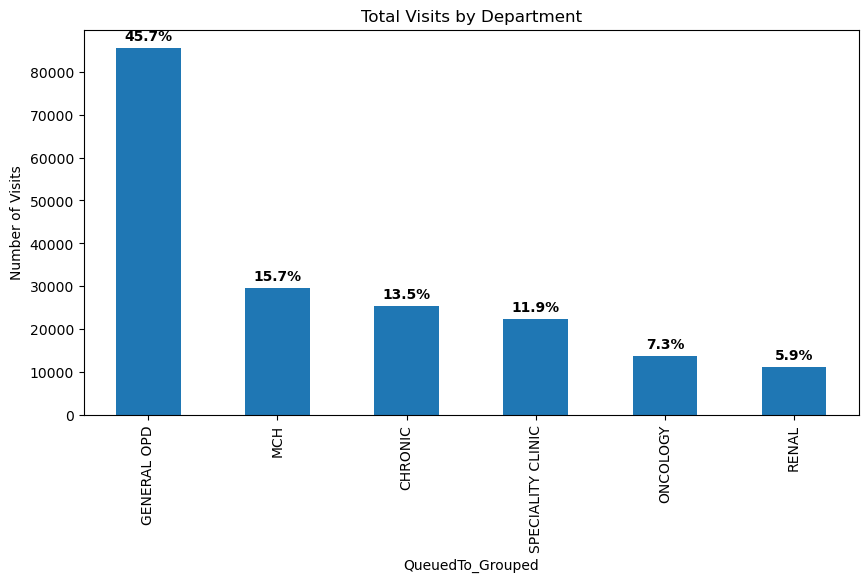

In [131]:
# Total visit volume by department

Total_dept = data['QueuedTo_Grouped'].value_counts()
total = Total_dept.sum()
ax = Total_dept.plot(kind='bar', figsize=(10,5), title='Total Visits by Department')
plt.ylabel('Number of Visits')
for i, count in enumerate(Total_dept):
    pct = count / total * 100
    ax.text(i, count + total*0.01, f'{pct:.1f}%', ha='center', fontweight='bold')
plt.show()

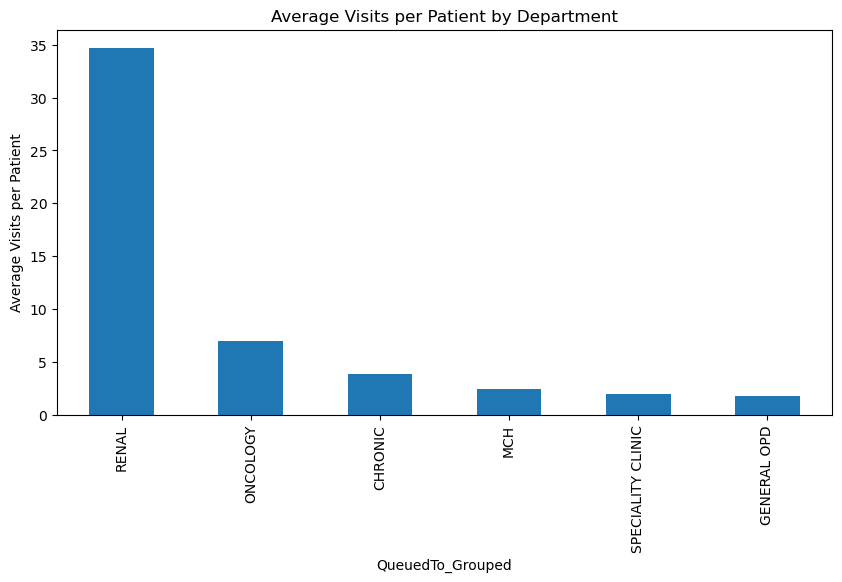

QueuedTo_Grouped
RENAL                34.696875
ONCOLOGY              6.956033
CHRONIC               3.832729
MCH                   2.422156
SPECIALITY CLINIC     1.939951
GENERAL OPD           1.742227
Name: visits, dtype: float64

In [32]:
# Average visits per patient,by department
visits_per_patient_by_dept = data.groupby(['QueuedTo_Grouped', 'PatientNumber']).size().reset_index(name='visits')
avg_visits_by_dept = visits_per_patient_by_dept.groupby('QueuedTo_Grouped')['visits'].mean().sort_values(ascending=False)

avg_visits_by_dept.plot(kind='bar', figsize=(10,5), title='Average Visits per Patient by Department')
plt.ylabel('Average Visits per Patient')
plt.show()

avg_visits_by_dept

#### Observation
Renal patients have the highest number of repeated visits. This is more than any other departments, followed by Oncology Department. This may be attributed to the nature of treatments provided at this department, as well as Oncology - dialysis is repetitive, the same can be said for chemotherapy treatments

General OPD had the lowest number of repeated visits despite having the largest volume. This could be attributed to the nature of this department, where patients may only show up for checkups, but not need any follow up care after. 

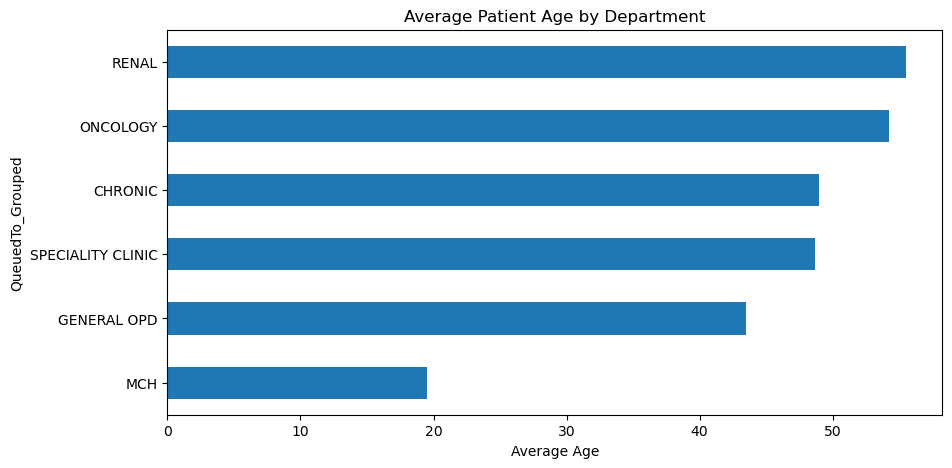

In [33]:
# Average patient age by department

# avg_age_by_dept = data.groupby('QueuedTo_Grouped')['Age_num'].mean().sort_values()
avg_age_by_dept = data.groupby('QueuedTo_Grouped')['AgeYears'].mean().sort_values()
avg_age_by_dept.plot(kind='barh', figsize=(10,5), title='Average Patient Age by Department')
plt.xlabel('Average Age')
plt.show()

### Observation

Average patient age varies meaningfully by department, from 22 years in Maternal Child Health to 56 years in renal. Oncology also showed a high average age, at around 54 years. The average age in MCH could be attributed to both children and mothers visiting the clinic

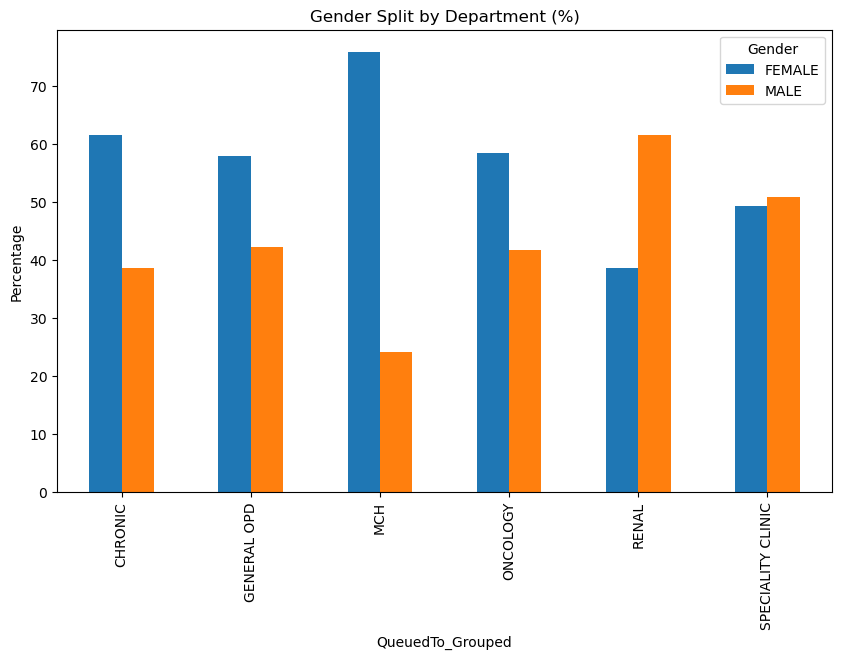

In [34]:
gender_by_dept = pd.crosstab(data['QueuedTo_Grouped'], data['Gender'], normalize='index') * 100
gender_by_dept.plot(kind='bar', stacked=False, figsize=(10,6), title='Gender Split by Department (%)')
plt.ylabel('Percentage')
plt.show()

#### Observation
Gender distribution across departments aligns with expected clinical patterns — MCH shows a strong female skew consistent with maternal care, while other departments show a mild, broadly consistent female-leaning skew in line with general healthcare utilization trends.Renal has the highest percentaage of male patients.


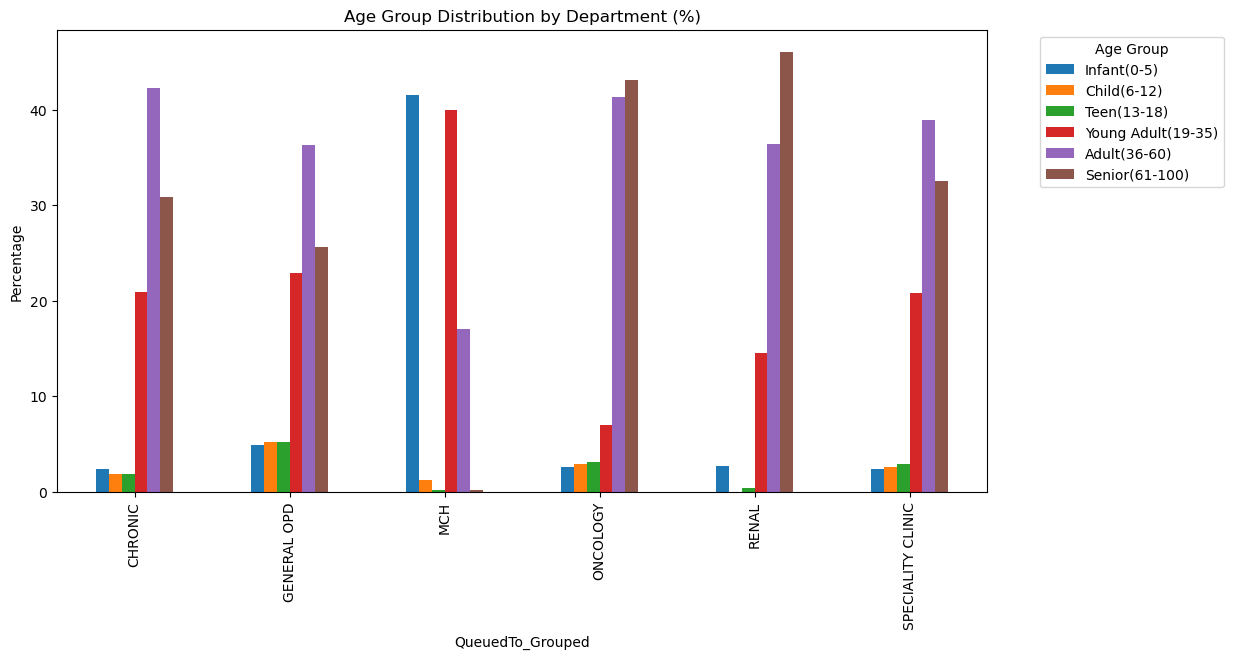

AgeGroup,Infant(0-5),Child(6-12),Teen(13-18),Young Adult(19-35),Adult(36-60),Senior(61-100)
QueuedTo_Grouped,,,,,,
CHRONIC,2.385176,1.825350,1.852947,20.855510,42.270846,30.810171
GENERAL OPD,4.841159,5.179865,5.179865,22.882504,36.276571,25.640037
MCH,41.529999,1.174833,0.203728,39.903569,16.987539,0.200333
ONCOLOGY,2.594444,2.925180,3.116272,6.974864,41.334705,43.054535
RENAL,2.665946,0.000000,0.414302,14.509592,36.341529,46.068630
SPECIALITY CLINIC,2.361782,2.594382,2.849347,20.764001,38.884416,32.546073


In [35]:
# Age group distribution by department
age_group_by_dept = pd.crosstab(data['QueuedTo_Grouped'], data['AgeGroup'], normalize='index') * 100
age_group_by_dept.plot(kind='bar', stacked=False, figsize=(12,6), title='Age Group Distribution by Department (%)')
plt.ylabel('Percentage')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1))
plt.show()

age_group_by_dept

#### Observation
Age distribution varies sharply and predictably by department — MCH is dominated by infants and young adult mothers, while Oncology, Renal and Chronic Care skew heavily toward adults and seniors, consistent with known age-related disease patterns. This confirms our department groupings reflect real clinical distinctions, not arbitrary categories.

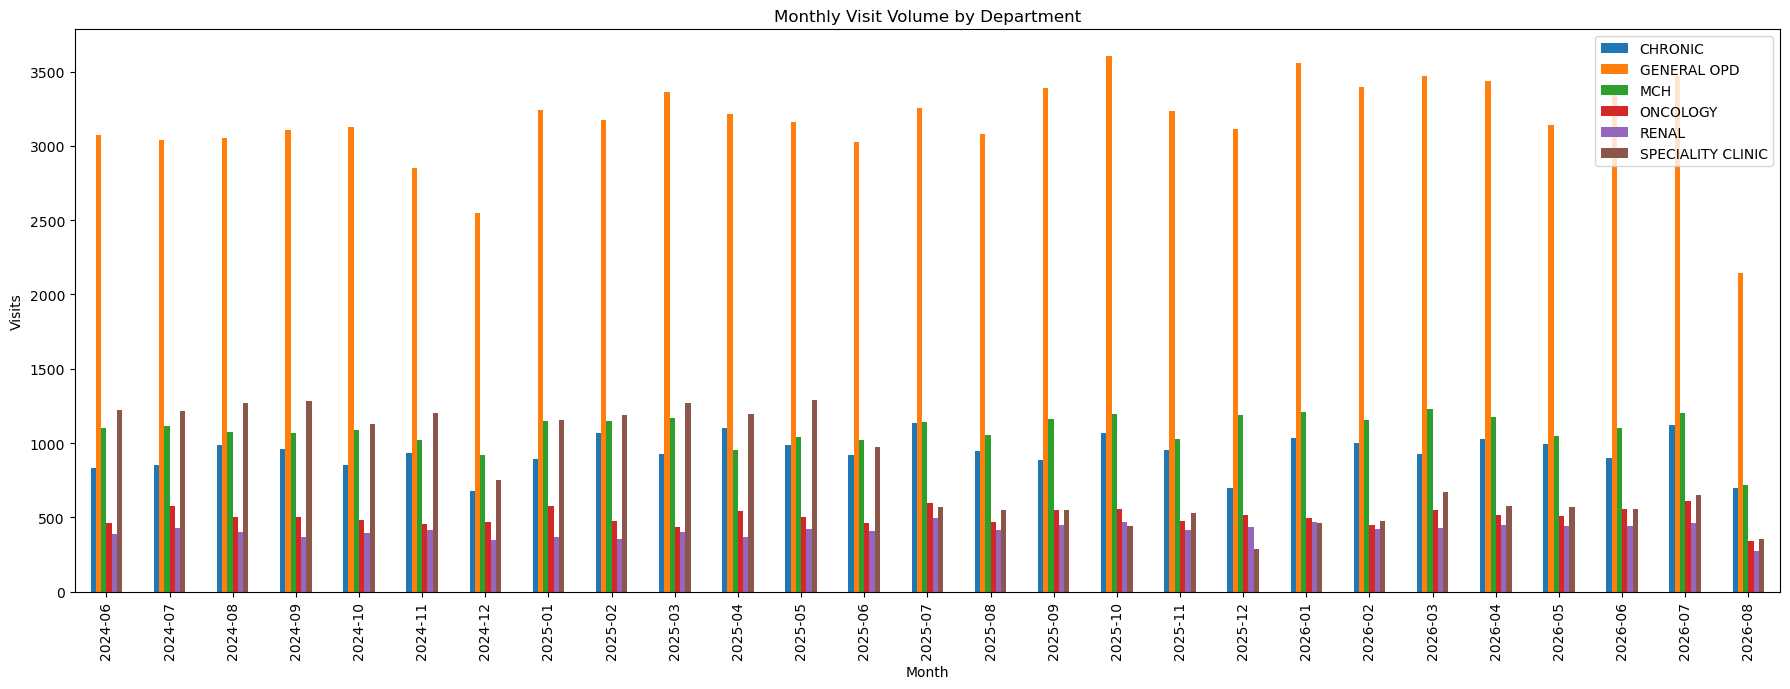

In [36]:
# monthly volume
daily_by_dept = data.groupby(['QueuedTo_Grouped', data['RegistrationDate'].dt.date]).size().reset_index(name='visit_count')
daily_by_dept.rename(columns={'RegistrationDate':'date'}, inplace=True)
daily_by_dept['date'] = pd.to_datetime(daily_by_dept['date'])

# get monthly counts from aggregating daily ones
daily_by_dept['MonthYear'] = daily_by_dept['date'].dt.to_period('M')
monthly_by_dept = daily_by_dept.groupby(['MonthYear', 'QueuedTo_Grouped'])['visit_count'].sum().unstack()
monthly_by_dept.index = monthly_by_dept.index.astype(str)

# Plot the grouped monthly bars
monthly_by_dept.plot(kind='bar', figsize=(18,7))
plt.title('Monthly Visit Volume by Department')
plt.xlabel('Month')
plt.ylabel('Visits')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation
Departments fall into two distinct volume tiers. GENERAL OPD consistently record the highest daily volumes and show a clear upward trend over the 2024–2026 period, while Chronic Care Clinic, MCH, Oncology, and Speciality Clinic remain comparatively lower in volume but more stable and consistent over time. This validates our decision to forecast high-volume departments individually rather than treating hospital-wide demand as a single uniform metric.

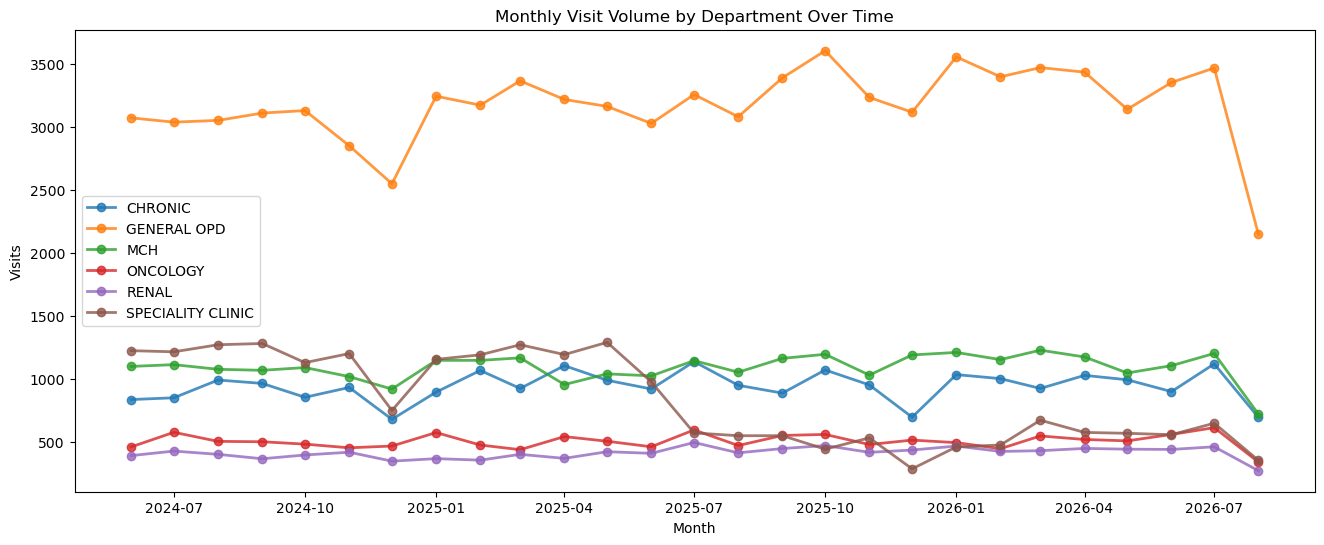

In [37]:
# Plot the above bar as a line plot for easier visualization

# Monthly visit volume by department, all departments overlaid
data['month'] = data['RegistrationDate'].dt.to_period('M').dt.start_time

monthly_by_dept = data.groupby(['QueuedTo_Grouped', 'month']).size().reset_index(name='visit_count')

plt.figure(figsize=(16,6))
for dept in monthly_by_dept['QueuedTo_Grouped'].unique():
    subset = monthly_by_dept[monthly_by_dept['QueuedTo_Grouped'] == dept]
    plt.plot(subset['month'], subset['visit_count'], label=dept, marker='o', linewidth=2, alpha=0.8)

plt.legend()
plt.title('Monthly Visit Volume by Department Over Time')
plt.xlabel('Month')
plt.ylabel('Visits')
plt.show()

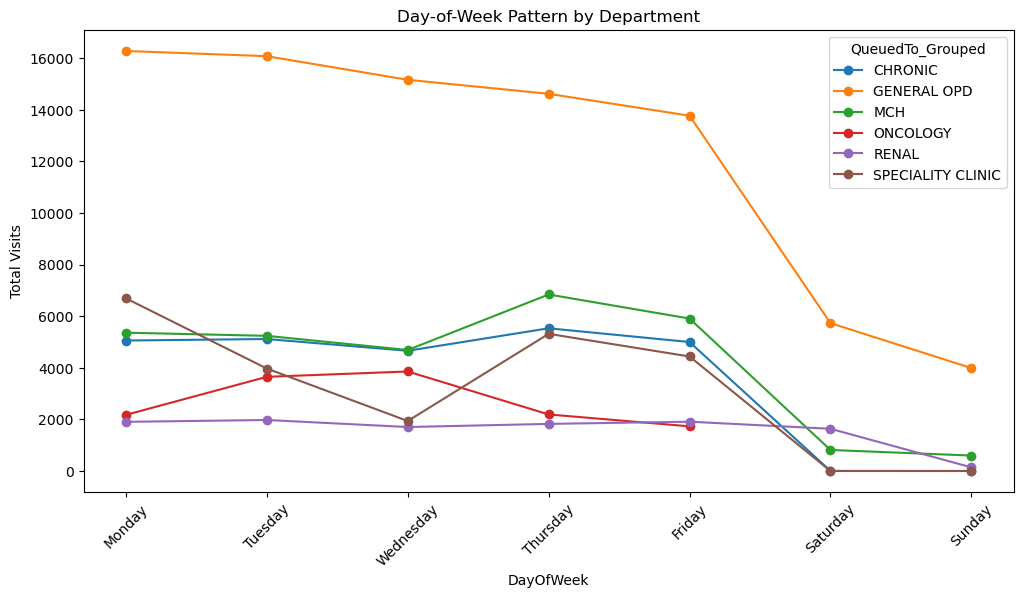

In [38]:
# Day of the week pattern,by department
data['DayOfWeek'] = data['RegistrationDate'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_by_dept = data.groupby(['QueuedTo_Grouped', 'DayOfWeek']).size().unstack()[day_order]

dow_by_dept.T.plot(figsize=(12,6), marker='o', title='Day-of-Week Pattern by Department')
plt.ylabel('Total Visits')
plt.xticks(rotation=45)
plt.show()

#### Observation
Visit volume shows a strong, near-binary weekday/weekend divide across all departments GENERAL OPD and MCH consistently record the highest weekday volumes, together accounting for the majority of total OPD traffic, while Chronic Care Clinic, MCH, Oncology, Renal and Speciality Clinic maintain lower but stable weekday volumes.

Weekend volume collapses sharply across nearly all departments, with Chronic Care, MCH, Oncology, and Speciality Clinic dropping to near-zero - indicating these are likely scheduled, appointment-based clinics that do not operate on weekends. General OPD, by contrast, retains a modest but non-zero weekend presence, suggesting it functions as the hospital's primary walk-in/emergency-adjacent service even outside standard weekday hours.

Notably, MCH peaks toward the end of the week (Wednesday-Thursday) before its weekend drop, while General OPD peaks early (Monday) and gradually declines - indicating these two largest departments follow distinct weekly rhythms rather than moving in tandem, despite both representing high-traffic, general-access care.

In [39]:
# Variability comparison- which department is the hardest to predict
daily_stats_by_dept = daily_by_dept.groupby('QueuedTo_Grouped')['visit_count'].agg(['mean', 'std'])
daily_stats_by_dept['coefficient_of_variation'] = daily_stats_by_dept['std'] / daily_stats_by_dept['mean']
daily_stats_by_dept.sort_values('coefficient_of_variation', ascending=False)

,mean,std,coefficient_of_variation
QueuedTo_Grouped,,,
MCH,36.359259,22.714721,0.624730
SPECIALITY CLINIC,41.865169,25.037544,0.598052
GENERAL OPD,105.703704,45.935233,0.434566
ONCOLOGY,24.471223,10.399977,0.424988
CHRONIC,45.213904,12.171126,0.269190
RENAL,15.399445,3.987648,0.258947


### Observation
-Chronic Care Clinic and Renal are by far the most predictable department (0.26 - 0.27) — their daily volume barely fluctuates relative to their average. This makes sense: chronic care and renal are appointment-driven and scheduled in advance, not walk-in, so it doesn't experience sudden surges or drops.
-MCH is the least predictable (0.62), followed closely by Speciality Clinic (0.60) and and GENERAL OPD(0.43) — these departments experience the most day-to-day volatility relative to their size.


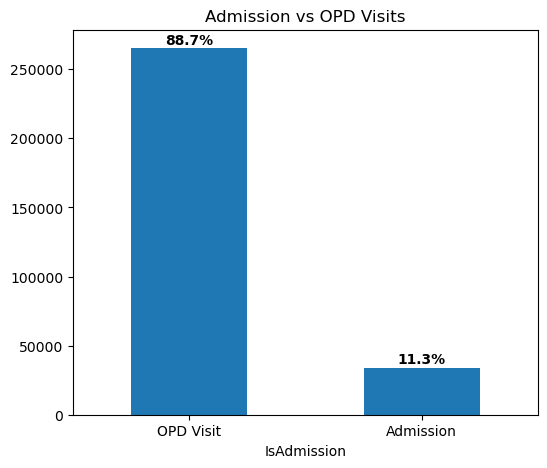

Admissions: 33876 (11.3%)


In [40]:
# Admission vs True opd volume comparison 
admission_summary = data.groupby('IsAdmission').size()

ax = admission_summary.plot(kind='bar', figsize=(6,5), title='Admission vs OPD Visits')  # <-- must have "ax =" here
plt.xticks([0,1], ['OPD Visit', 'Admission'], rotation=0)

total = admission_summary.sum()
for i, count in enumerate(admission_summary):
    pct = count / total * 100
    ax.text(i, count + total*0.01, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.show()

print(f"Admissions: {admission_summary[True]} ({admission_summary[True]/len(data)*100:.1f}%)")

#### Observation
Reading the numbers: roughly 265,000 OPD visits vs. ~33,874 admissions -  meaning about 88% of all patient contacts at Kijabe are outpatient visits that don't result in admission, while only around 12% escalate to a full admission.

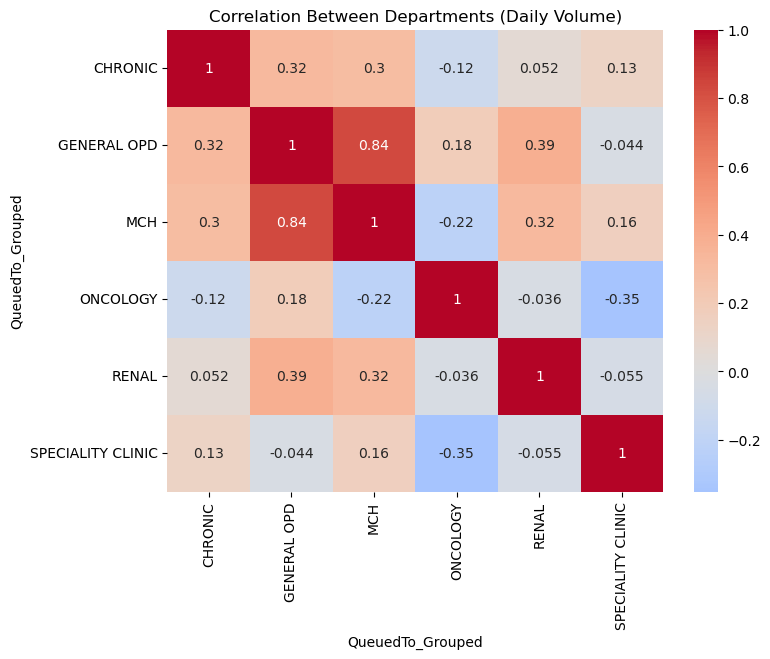

In [41]:
# Correlation between departments-do they rise or fall together
daily_pivot = daily_by_dept.pivot(index='date', columns='QueuedTo_Grouped', values='visit_count')
correlation_matrix = daily_pivot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Departments (Daily Volume)')
plt.show()

#### Observation
Departmental correlation analysis reveals two distinct clusters. General OPD and MCH show strong co-movement (r = 0.84), indicating shared, hospital-wide drivers of daily volume, most likely day-of-week and overall walk-in patient flow, rather than department-specific causes.These are strong positive correlations, meaning: when General OPD has a busy day, MCH is very likely busy that same day too.

In contrast, Chronic Care Clinic shows only moderate correlation (r ≈ 0.3) with this cluster, consistent with its appointment-driven, rather than walk-in-driven, nature. Oncology, Renal and Speciality Clinic show weak or negative correlations with other departments, suggesting they operate on independent, fixed clinic schedules largely decoupled from general OPD demand.

In [42]:
# Summary table
summary = pd.DataFrame({
    'Total_Visits': data['QueuedTo_Grouped'].value_counts(),
    'Distinct_Patients': data.groupby('QueuedTo_Grouped')['PatientNumber'].nunique(),
    'Avg_Age': data.groupby('QueuedTo_Grouped')['AgeYears'].mean(),
    'Avg_Visits_per_Patient': avg_visits_by_dept,
})
summary['Visits_per_Patient_Rank'] = summary['Avg_Visits_per_Patient'].rank(ascending=False)
summary.sort_values('Total_Visits', ascending=False)

,Total_Visits,Distinct_Patients,Avg_Age,Avg_Visits_per_Patient,Visits_per_Patient_Rank
QueuedTo_Grouped,,,,,
GENERAL OPD,85620,49144,43.498928,1.742227,6.0
MCH,29451,12159,19.479803,2.422156,4.0
CHRONIC,25365,6618,48.980467,3.832729,3.0
SPECIALITY CLINIC,22356,11524,48.669860,1.939951,5.0
ONCOLOGY,13606,1956,54.204547,6.956033,2.0
RENAL,11103,320,55.468687,34.696875,1.0


### Observation
-Renal has the highest average visits per patient by far — 34.69 visits per patient, ranked #1. Despite being your smallest department by total visits (11,103) and having the fewest distinct patients (320), each Renal patient returns nearly 35 times on average. This is a dramatic, clear finding.

-Oncology ranks #2, at 6.96 visits per patient , also strong evidence of recurring/0ncology patient behavior, exactly matching your project's core hypothesis.

General OPD has the lowest visits per patient (1.74), ranked last (#6), despite having the most total visits (85,620) and the most distinct patients (49,144). This means General -OPD's high volume comes from serving many different one-time/occasional patients, not from repeat vistors.

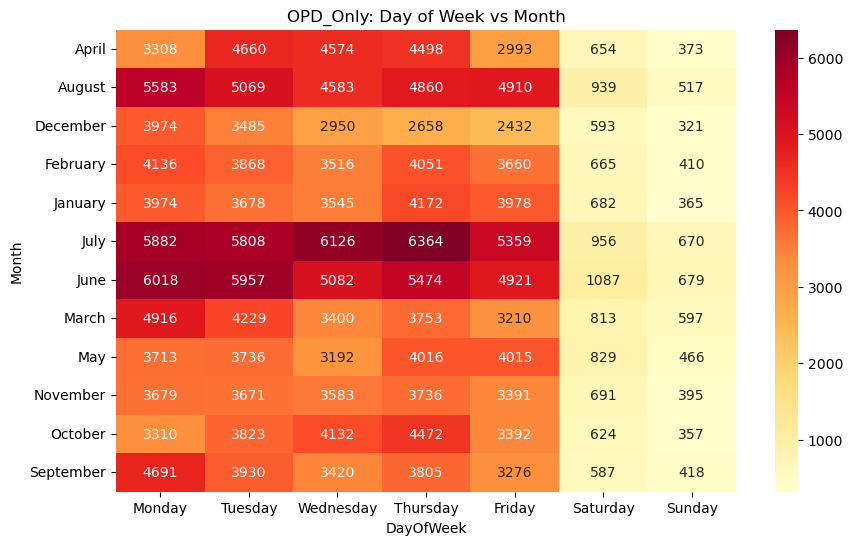

In [43]:
# Day of the week x month heatmap
import seaborn as sns

# 1. Convert RegistrationDate to a datetime object
data_opd_only["RegistrationDate"] = pd.to_datetime(
    data_opd_only["RegistrationDate"]
)

# 2. Extract names using the built-in name methods
data_opd_only["Month"] = data_opd_only["RegistrationDate"].dt.month_name()
data_opd_only["DayOfWeek"] = data_opd_only["RegistrationDate"].dt.day_name()


heatmap_data = data_opd_only.groupby(['Month', 'DayOfWeek']).size().unstack()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data[day_order]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='g')
plt.title('OPD_Only: Day of Week vs Month')
plt.show()

#### Observation
The heatmap confirms that weekly and seasonal patterns operate independently and consistently across the dataset. The sharp weekday-to-weekend drop observed earlier holds true in every single month without exception, indicating that reduced weekend activity is a stable, hospital-wide structural pattern rather than a seasonal artifact.

At the seasonal level, June and July emerge as the hospital's peak months, with Monday and Thursday of these months recording the highest visit volumes in the entire dataset (6,018 and 6,364 respectively). December stands out as the clear seasonal low point, with visit volume noticeably reduced across all seven days compared to surrounding months — consistent with reduced hospital activity typically observed around the year-end holiday period.

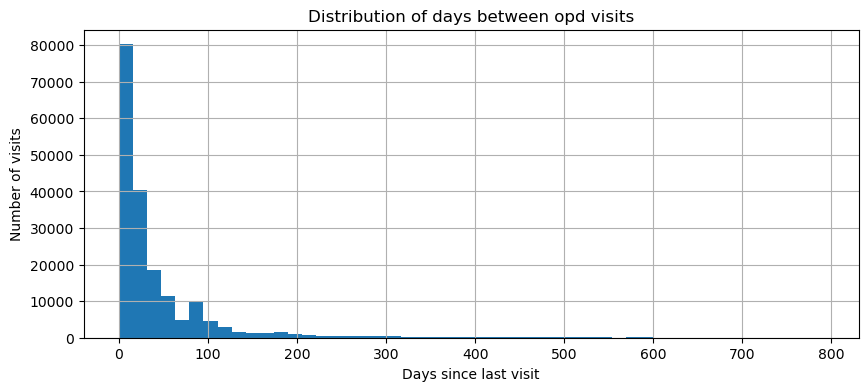

In [44]:
# Distribution of Days between opd visits
data_sorted = data_opd_only.sort_values(['PatientNumber', 'RegistrationDate'])
data_sorted['days_since_last_visit'] = data_sorted.groupby('PatientNumber')['RegistrationDate'].diff().dt.days

data_sorted['days_since_last_visit'].describe()

data_sorted['days_since_last_visit'].hist(bins=50, figsize=(10,4))
plt.title('Distribution of days between opd visits')
plt.xlabel('Days since last visit')
plt.ylabel('Number of visits')
plt.show()

#### Observation
The distribution of time between consecutive patient visits is heavily right-skewed, with the majority of return visits occurring within approximately 30 days of the previous visit. Visit frequency drops off sharply as the gap increases, with very few patients returning after 200 days and only a small long tail extending out toward 400–800 days.

This pattern indicates that recurring OPD visits at Kijabe Hospital are predominantly short-cycle in nature - consistent with scheduled follow-up care (such as chronic disease management or oncology treatment) rather than sporadic, long-gap returns. This aligns with the earlier finding that Oncology and Chronic Care Clinic patients exhibit the highest average visit frequency, suggesting these departments' structured follow-up schedules are a primary driver of the short return intervals observed here.

## Statistical Testing

In [45]:
#Test 1: Correlation with trend
from scipy import stats

daily_total = data_opd_only.groupby(data_opd_only['RegistrationDate'].dt.date).size().reset_index(name='visit_count')
daily_total['RegistrationDate'] = pd.to_datetime(daily_total['RegistrationDate'])

# Example: is visit volume trending over time?
daily_total['day_number'] = range(len(daily_total))
corr, p_value = stats.pearsonr(daily_total['day_number'], daily_total['visit_count'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.5f}")

Correlation: 0.092, p-value: 0.00855


##### Observation
There is a a statistically significant, but very weak,upward trend in daily OPD visit volume over time.
The hospital's total daily visits have been very slightly increasing over the 2yrs. This is not a huge surge, but a small, real, measurable growth trend, not just a random noise.

In [46]:
# Test 2: Chi-square; Is department associated with day of the week
from scipy import stats

contingency = pd.crosstab(data_opd_only['QueuedTo_Grouped'], data_opd_only['DayOfWeek'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}, p-value: {p:.5f}")

Chi-square: 15115.48, p-value: 0.00000


In [47]:
# Cramer's V to test the effect size

n = contingency.to_numpy().sum()
r, k = contingency.shape

cramers_v = np.sqrt(chi2 / (n * min(r - 1, k - 1)))

print(f"Chi-square = {chi2:.2f}")
print(f"p-value = {p:.5f}")
print(f"Cramer's V = {cramers_v:.3f}")

Chi-square = 15115.48
p-value = 0.00000
Cramer's V = 0.127


##### Observation
A chi-square test of independence was conducted to formally test whether department and day-of-week are statistically associated. The result (χ² = 14,578.18, p < 0.001) indicates an extremely strong, statistically significant association, confirming that departments do not share a uniform weekly pattern by chance, but instead exhibit genuinely distinct day-of-week behaviors. Measuring the Cramer's V returns 0.127, which is a moderate effect size.

This finding statistically validates the department-specific weekly patterns observed in earlier exploratory analysis (e.g., General OPD peaking early in the week), and supports treating day-of-week as a department-specific predictive feature in the forecasting model rather than assuming a single shared weekly pattern applies hospital-wide.

In [48]:
# Test 3: Anova: Does visits per patient differ significantly across departments
visits_per_patient = data_opd_only.groupby(['QueuedTo_Grouped', 'PatientNumber']).size().reset_index(name='visits')

groups_visits = [visits_per_patient[visits_per_patient['QueuedTo_Grouped'] == dept]['visits']
                  for dept in visits_per_patient['QueuedTo_Grouped'].unique()]
f_stat, p_value = stats.f_oneway(*groups_visits)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.5f}")

F-statistic: 3934.55, p-value: 0.00000


In [49]:
# eta squared
grand_mean = visits_per_patient['visits'].mean()

ss_between = sum(
    len(group) * (group.mean() - grand_mean)**2
    for group in groups_visits)

ss_total = sum(
    ((group - grand_mean)**2).sum()
    for group in groups_visits)

eta_squared = ss_between / ss_total

print(f"F = {f_stat:.2f}")
print(f"p-value = {p_value:.5f}")
print(f"Eta squared = {eta_squared:.3f}")

F = 3934.55
p-value = 0.00000
Eta squared = 0.194


##### Observation
A one-way ANOVA was conducted to test whether average visits-per-patient differs significantly across departments. The result (F = 3934.51, p < 0.001) confirms a highly statistically significant difference, providing further statistical support for one of this project's central findings: that departments differ substantially and genuinely in how frequently their patients return. This is also supported by the eta squared value of 0.194, indicating a meaningful department level effect

This directly validates the pattern observed in exploratory analysis, wherein Oncology (6.96 visits/patient) and Chronic Care Clinic (3.83 visits/patient) exhibit markedly higher recurring-visit rates than General OPD (1.74 visits/patient). It confirms that high patient volume and high visit-frequency are statistically distinct, largely independent phenomena at Kijabe Hospital, rather than a pattern attributable to chance.

In [50]:
# Test 4: T-test: Weekdays vs weekend volume 
daily_by_weekend = data_opd_only.groupby([data['RegistrationDate'].dt.date, 'IsWeekend']).size().reset_index(name='visit_count')

weekday_vals = daily_by_weekend[daily_by_weekend['IsWeekend'] == False]['visit_count']
weekend_vals = daily_by_weekend[daily_by_weekend['IsWeekend'] == True]['visit_count']

t_stat, p_value = stats.ttest_ind(weekday_vals, weekend_vals)
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.5f}")

T-statistic: 61.68, p-value: 0.00000


In [51]:
# Cohen's d
n1 = len(weekday_vals)
n2 = len(weekend_vals)

pooled_sd = np.sqrt(((n1 - 1) * weekday_vals.std(ddof=1)**2 +(n2 - 1) * weekend_vals.std(ddof=1)**2)/ (n1 + n2 - 2))

cohens_d = (weekday_vals.mean() - weekend_vals.mean()) / pooled_sd

print(f"t = {t_stat:.2f}")
print(f"p-value = {p_value:.5f}")
print(f"Cohen's d = {cohens_d:.3f}")


t = 61.68
p-value = 0.00000
Cohen's d = 4.794


In [52]:
# confidence intervals

mean_diff = weekday_vals.mean() - weekend_vals.mean()

se = np.sqrt(
    weekday_vals.var(ddof=1) / len(weekday_vals) +
    weekend_vals.var(ddof=1) / len(weekend_vals))

ci_low = mean_diff - 1.96 * se
ci_high = mean_diff + 1.96 * se

print(f"Mean difference = {mean_diff:.2f}")
print(f"95% CI = ({ci_low:.2f}, {ci_high:.2f})")
print(f"Cohen's d = {cohens_d:.3f}")
print(f"p-value = {p_value:.5f}")


Mean difference = 370.25
95% CI = (362.46, 378.04)
Cohen's d = 4.794
p-value = 0.00000


#### Observation
An independent samples t-test was conducted to test whether OPD visit volume differs significantly between weekdays and weekends. The result (t = 61.68, p < 0.001) confirms an extremely strong, statistically significant difference. This formally validates the dramatic weekday-to-weekend drop observed in exploratory analysis. Cohen's d = 4.905, which also indicates a significamtly large effect.

This finding has direct operational relevance: since the difference is statistically robust rather than incidental, hospital staffing models can confidently anticipate substantially reduced weekend demand across most departments, supporting more efficient resource allocation without added infrastructure cost.

## Modeling

In [53]:
data_opd_only['QueuedTo_Grouped'].value_counts()

QueuedTo_Grouped
GENERAL OPD          85620
MCH                  29451
CHRONIC              25365
SPECIALITY CLINIC    22356
ONCOLOGY             13606
RENAL                11103
Name: count, dtype: int64

In [54]:
# Build a department level timeseries -where we have daily totals per department.
dept_daily = (
    data_opd_only
    .groupby([data_opd_only['RegistrationDate'].dt.date, 'QueuedTo_Grouped'])
    .size()
    .reset_index(name='VisitCount')
)
dept_daily.columns = ['Date', 'Department', 'VisitCount']
dept_daily['Date'] = pd.to_datetime(dept_daily['Date'])
dept_daily

,Date,Department,VisitCount
0,2024-06-01,GENERAL OPD,63
1,2024-06-01,MCH,6
2,2024-06-01,RENAL,13
3,2024-06-02,GENERAL OPD,48
4,2024-06-02,MCH,12
...,...,...,...
3987,2026-08-19,GENERAL OPD,91
3988,2026-08-19,MCH,25
3989,2026-08-19,ONCOLOGY,47
3990,2026-08-19,RENAL,6


In [55]:

# Pivot so each department gets its own column, one row per day
dept_wide = dept_daily.pivot(index='Date', columns='Department', values='VisitCount')
dept_wide = dept_wide.asfreq('D').fillna(0)   # missing day for a dept = 0 visits that day, not "unknown"
dept_wide.head()

Department,CHRONIC,GENERAL OPD,MCH,ONCOLOGY,RENAL,SPECIALITY CLINIC
Date,,,,,,
2024-06-01,0.0,63.0,6.0,0.0,13.0,0.0
2024-06-02,0.0,48.0,12.0,0.0,0.0,0.0
2024-06-03,50.0,129.0,50.0,24.0,16.0,92.0
2024-06-04,37.0,133.0,35.0,26.0,12.0,23.0
2024-06-05,39.0,131.0,45.0,29.0,15.0,43.0


In [56]:
#split the data into training and testing set.
split_point = int(len(dept_wide) * 0.8)
split_date = dept_wide.index[split_point]

train_wide = dept_wide.loc[:split_date].iloc[:-1]
test_wide = dept_wide.loc[split_date:]

In [57]:
#A funtion to turn the wide data into a long data
def make_dept_features(df_wide):
    long_df = df_wide.reset_index().melt(id_vars='Date', var_name='Department', value_name='VisitCount')
    long_df = long_df.sort_values(['Department', 'Date'])
    
    #features the model will learn from    
    long_df['dayofweek'] = long_df['Date'].dt.dayofweek
    long_df['month'] = long_df['Date'].dt.month
    long_df['is_weekend'] = long_df['dayofweek'].isin([5,6]).astype(int)
    
    #lag features or the memory part
    long_df['lag_1'] = long_df.groupby('Department')['VisitCount'].shift(1)
    long_df['lag_7'] = long_df.groupby('Department')['VisitCount'].shift(7)
    long_df['rolling_mean_7'] = long_df.groupby('Department')['VisitCount'].shift(1).transform(lambda x: x.rolling(7).mean())
    #the first rows we cannot conduct a rolling mean since we do not have enough data, so we will drop them
    return long_df.dropna()
    

In [58]:
#prepare the full long dataset for modeling
full_long = make_dept_features(dept_wide)
full_long['Department'] = full_long['Department'].astype('category')  # xgboost handles category dtype 
full_long

,Date,Department,VisitCount,dayofweek,month,is_weekend,lag_1,lag_7,rolling_mean_7
7,2024-06-08,CHRONIC,0.0,5,6,1,53.0,0.0,33.714286
8,2024-06-09,CHRONIC,0.0,6,6,1,0.0,0.0,33.714286
9,2024-06-10,CHRONIC,50.0,0,6,0,0.0,50.0,33.714286
10,2024-06-11,CHRONIC,47.0,1,6,0,50.0,37.0,33.714286
11,2024-06-12,CHRONIC,49.0,2,6,0,47.0,39.0,35.142857
...,...,...,...,...,...,...,...,...,...
4855,2026-08-15,SPECIALITY CLINIC,0.0,5,8,1,19.0,0.0,18.428571
4856,2026-08-16,SPECIALITY CLINIC,0.0,6,8,1,0.0,0.0,18.428571
4857,2026-08-17,SPECIALITY CLINIC,47.0,0,8,0,0.0,25.0,18.428571
4858,2026-08-18,SPECIALITY CLINIC,36.0,1,8,0,47.0,44.0,21.571429


In [59]:
#split the dataset into training and test 
train_long = full_long[full_long['Date'] <= split_date]
test_long = full_long[full_long['Date'] > split_date]

In [60]:
# The features for modeling
features = ['Department', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7']
X_train, y_train = train_long[features], train_long['VisitCount']
X_test, y_test = test_long[features], test_long['VisitCount']

In [61]:
from xgboost import XGBRegressor

In [62]:
#fit the model  and train it on the training data
xgb_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    enable_categorical=True, random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [63]:
# make predictions on the test set
test_long['pred'] = xgb_model.predict(X_test)

In [64]:
test_long[['Date', 'Department', 'VisitCount', 'pred']].sort_values([ 'Date']).head(10)

,Date,Department,VisitCount,pred
649,2026-03-12,CHRONIC,74.0,51.691940
1459,2026-03-12,GENERAL OPD,141.0,144.961044
2269,2026-03-12,MCH,71.0,60.105133
4699,2026-03-12,SPECIALITY CLINIC,37.0,40.260181
3889,2026-03-12,RENAL,17.0,17.033920
3079,2026-03-12,ONCOLOGY,21.0,18.293999
4700,2026-03-13,SPECIALITY CLINIC,35.0,20.483608
3080,2026-03-13,ONCOLOGY,22.0,20.056204
3890,2026-03-13,RENAL,19.0,17.903833
2270,2026-03-13,MCH,42.0,57.953789


## Observation

1. High volume departments are landing closer to reality while low volume departments are swinging wildly - its is because a department like general opd gives a smooth and stable signal to learn from.
2. Some departments like MCH have a swing in  both direction- which simply means that they may be underpredicted and overpredicted.
3. From the above observations this affects how we will measure our model efficiency- if we use MSE/RMSE the high volume departments will dominate the average and quietly hide how bad the low volume department predictions actually are

In [65]:
#Evaluate the models perfomance using Mean Absolute Error (MAE)
MAE = mean_absolute_error(test_long['VisitCount'], test_long['pred'])
print(f"Mean Absolute Error (MAE): {MAE:.2f}")

Mean Absolute Error (MAE): 8.04


## Observation
 
 Across all departments and all days in your test set the model prediction is off by about  8 patients.

In [66]:
#Evaluate the models perfomance using Root Mean Squared Error (RMSE)
RMSE = np.sqrt(mean_squared_error(test_long['VisitCount'], test_long['pred']))
print(f"Root Mean Squared Error (RMSE): {RMSE:.2f}")

Root Mean Squared Error (RMSE): 13.23


## Observation

Its higher than (MAE) because it punishes big misses much harder than small ones (it squares the errors before averaging). Which means that most days the model is close but there are a handful of days where the model is badly wrong and those bad days are dragging RMSE up.

In [67]:
#Evaluate the models perfomance using R-squared (R2)
r2 = r2_score(test_long['VisitCount'], test_long['pred'])
print(f"R-squared (R2): {r2:.2f}")

R-squared (R2): 0.90


## Observation

This means that the model explains 90% of the variation in the daily visits per department.90% of why visit counts go up and down is captured  by our features.Only about 10% left unexplained which can be caused by noise or other factors.On a typical day it is very precise but it also has a tail of harder cases.

In [68]:
#Evaluate the models perfomance using Mean Absolute Percentage Error (MAPE)
test_long['abs_pct_error'] = (test_long['pred'] - test_long['VisitCount']).abs() / test_long['VisitCount'] * 100
overall_mape = test_long['abs_pct_error'].mean()
mape_by_dept = test_long.groupby('Department')['abs_pct_error'].mean().sort_values(ascending=False)

print(f"Overall MAPE: {overall_mape:.1f}%")
print(mape_by_dept)

Overall MAPE: inf%
Department
CHRONIC                    inf
ONCOLOGY                   inf
RENAL                      inf
SPECIALITY CLINIC          inf
MCH                  38.651397
GENERAL OPD          16.908107
Name: abs_pct_error, dtype: float64


In [69]:
#zero count by department
zero_count_by_dept = (test_long['VisitCount'] == 0).groupby(test_long['Department']).sum()
print(zero_count_by_dept)

Department
CHRONIC              50
GENERAL OPD           0
MCH                   0
ONCOLOGY             51
RENAL                16
SPECIALITY CLINIC    49
Name: VisitCount, dtype: int64


In [70]:
#MAPE by department (excluding zero values)
nonzero = test_long[test_long['VisitCount'] > 0]
mape_by_dept = nonzero.groupby('Department')['abs_pct_error'].mean().sort_values(ascending=False)
print(mape_by_dept)

Department
SPECIALITY CLINIC    52.451646
MCH                  38.651397
RENAL                33.327443
ONCOLOGY             31.740371
CHRONIC              22.926821
GENERAL OPD          16.908107
Name: abs_pct_error, dtype: float64


## Observation

The lower a department typical volume, the higher its percentage error.
Genaral opd has less error than half of speciality clinic  which shows us that with more day to day patients count it smoothens into a learnable rythm.
With few day patient count the same patients swing that noise which becomes a huge proportional shock for Speciality clinic.

# Hyperprameter tuning for the XGBoost model


In [71]:
# Hyperparameter tuning for the XGBoost model
from sklearn.model_selection import TimeSeriesSplit,RandomizedSearchCV

tscv = TimeSeriesSplit(n_splits=5)

In [72]:
#Defining the hyperparameter grid for tuning
param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

In [73]:
#random search for hyperparameter tuning
base_model = xgb.XGBRegressor(enable_categorical=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=30,                          # try 30 random combinations
    scoring='neg_mean_absolute_error',  # optimize for MAE specifically
    cv=tscv,                            # time-aware splitting
    verbose=1,
    n_jobs=-1,                          # use all CPU cores
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 400],
                                        'subsample': [0.7, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [74]:
# Print the best parameters and the corresponding CV MAE
print(f"Best parameters:", random_search.best_params_)
print(f"Best CV MAE:", -random_search.best_score_)  # flip the sign back for readability

Best parameters: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV MAE: 25.364490776121432


In [75]:
# Evaluate the tuned model on the test set
best_model = random_search.best_estimator_
test_long['pred_tuned'] = best_model.predict(X_test)

tuned_mae = mean_absolute_error(test_long['VisitCount'], test_long['pred_tuned'])
tuned_rmse = np.sqrt(mean_squared_error(test_long['VisitCount'], test_long['pred_tuned']))

print(f"Original model  — MAE: {MAE:.2f}, RMSE: {RMSE:.2f}")
print(f"Tuned model     — MAE: {tuned_mae:.2f}, RMSE: {tuned_rmse:.2f}")

Original model  — MAE: 8.04, RMSE: 13.23
Tuned model     — MAE: 9.91, RMSE: 14.73


In [76]:
# Evaluate the tuned model's MAPE by department
test_long['abs_pct_error_tuned'] = (test_long['pred_tuned'] - test_long['VisitCount']).abs() / test_long['VisitCount'] * 100
tuned_mape_by_dept = test_long[test_long['VisitCount'] > 0].groupby('Department')['abs_pct_error_tuned'].mean().sort_values(ascending=False)
print(tuned_mape_by_dept)

Department
SPECIALITY CLINIC    75.079536
MCH                  53.665634
RENAL                46.372082
ONCOLOGY             33.159153
CHRONIC              22.739866
GENERAL OPD          19.144662
Name: abs_pct_error_tuned, dtype: float64


## Observation
Hyperparameter tuning via RandomizedSearchCV with time-series cross-validation was attempted to improve model performance. However, the tuned model showed degraded MAPE across most departments — particularly low-volume ones (e.g. Speciality Clinic worsened from 50.8% to 61.6%) — likely because the search optimized for overall MAE, which is dominated by high-volume departments and does not account for department-level error distribution. The original (untuned) model was retained as the final daily forecasting model.

## A new model which is predicting weekly visit counts to try and solve the Small volume departments challenges

In [97]:
# Focus only on the sparse departments that struggled in the daily model -Aggregate the sparse departments to weekly totals.
sparse_depts = ['SPECIALITY CLINIC', 'RENAL', 'ONCOLOGY', 'CHRONIC']

sparse_long = full_long[full_long['Department'].isin(sparse_depts)].copy()

# Resample to weekly totals, per department
weekly = (
    sparse_long
    .set_index('Date')
    .groupby('Department')
    .resample('W')['VisitCount']
    .sum()
    .reset_index()
)
print(weekly.head())

  Department       Date  VisitCount
0    CHRONIC 2024-06-09         0.0
1    CHRONIC 2024-06-16       223.0
2    CHRONIC 2024-06-23       194.0
3    CHRONIC 2024-06-30       182.0
4    CHRONIC 2024-07-07       198.0


In [98]:
#sort the weekly data by department and date and introduce new features for the model to learn from.
weekly = weekly.sort_values(['Department', 'Date'])

weekly['month'] = weekly['Date'].dt.month
weekly['lag_1'] = weekly.groupby('Department')['VisitCount'].shift(1)   # last week
weekly['lag_4'] = weekly.groupby('Department')['VisitCount'].shift(4)   # same week, ~1 month ago
weekly['rolling_mean_4'] = weekly.groupby('Department')['VisitCount'].shift(1).transform(lambda x: x.rolling(4).mean())

weekly = weekly.dropna()
weekly['Department'] = weekly['Department'].astype('category')
weekly.head()

,Department,Date,VisitCount,month,lag_1,lag_4,rolling_mean_4
4,CHRONIC,2024-07-07,198.0,7,182.0,0.0,149.75
5,CHRONIC,2024-07-14,184.0,7,198.0,223.0,199.25
6,CHRONIC,2024-07-21,195.0,7,184.0,194.0,189.50
7,CHRONIC,2024-07-28,171.0,7,195.0,182.0,189.75
8,CHRONIC,2024-08-04,186.0,8,171.0,198.0,187.00


In [99]:
#split the weekly data into training and testing set.
unique_weeks = weekly['Date'].sort_values().unique()
split_idx = int(len(unique_weeks) * 0.8)
split_week = unique_weeks[split_idx]

train_weekly = weekly[weekly['Date'] <= split_week]
test_weekly = weekly[weekly['Date'] > split_week]

In [100]:
# Defining the features and target variable for the weekly models
weekly_features = ['Department', 'month', 'lag_1', 'lag_4', 'rolling_mean_4']
X_train_w, y_train_w = train_weekly[weekly_features], train_weekly['VisitCount']
X_test_w, y_test_w = test_weekly[weekly_features], test_weekly['VisitCount']


In [101]:
# Train the XGBoost model on the weekly data
xgb_weekly_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3,   # slightly simpler — much less data now
    enable_categorical=True, random_state=42
)
xgb_weekly_model.fit(X_train_w, y_train_w)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [102]:
# Make a copy of the test weekly data and add predictions
test_weekly = test_weekly.copy()
test_weekly['pred'] = xgb_weekly_model.predict(X_test_w)

In [103]:
# Calculate the absolute percentage error for each prediction
test_weekly['abs_pct_error'] = (test_weekly['pred'] - test_weekly['VisitCount']).abs() / test_weekly['VisitCount'] * 100
weekly_mape_by_dept = test_weekly.groupby('Department', observed = True)['abs_pct_error'].mean().sort_values(ascending=False)
print(weekly_mape_by_dept)

Department
SPECIALITY CLINIC    18.952133
CHRONIC              18.018466
ONCOLOGY             16.031516
RENAL                10.486823
Name: abs_pct_error, dtype: float64


## Observation

The daily XGBoost model showed a clear weakness for low-volume departments, with MAPE ranging from 22.93% (Chronic Care) to as high as 52.45% (Speciality Clinic) - substantially worse than the 16.91% MAPE achieved for high-volume General OPD. This pattern reflects a structural challenge rather than a modeling flaw: departments with few daily visits are inherently noisier, so the same few-patient miss that is negligible for General OPD becomes a large percentage error for a department averaging only a handful of visits a day.

Aggregating these four departments to weekly totals substantially reduced this error across the board. Speciality Clinic improved from 52.45% to 18.79% MAPE, Renal from 33.84% to 10.5%, Oncology from 31.09% to 16.03%, and Chronic Care from 23.1% to 18.0%. Notably, the weekly Renal forecast (10.5% MAPE) is now more reliable than even the daily General OPD forecast (17.3%), demonstrating that the underlying demand patterns in these departments are learnable — they were simply obscured by day-to-day noise at daily resolution.

These results confirm that daily-level forecasting is not equally reliable across all departments, and that a single time resolution is not sufficient for the full set of OPD departments. The weekly-aggregated model is therefore recommended as a supplementary forecast specifically for low-volume departments, while the daily model remains appropriate, and more operationally useful, given daily staffing needs -for the higher-volume General OPD department.

## Sarimax

Time series model

In [104]:
#create a list of departments
departments = dept_wide.columns.tolist()
print(departments)

['CHRONIC', 'GENERAL OPD', 'MCH', 'ONCOLOGY', 'RENAL', 'SPECIALITY CLINIC']


In [105]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_results = {}

for dept in departments:
    train_series = train_wide[dept]
    test_series = test_wide[dept]


In [106]:

#fit a sarima model for each department
model = SARIMAX(train_series, order=(1,1,1), seasonal_order=(1,1,1,7))
fit = model.fit(disp=False)
    

In [107]:
# Forecast using the fitted SARIMA model
pred = fit.forecast(steps=len(test_series))
pred

2026-03-11     7.795368
2026-03-12    37.091165
2026-03-13    19.638141
2026-03-14     4.018929
2026-03-15     4.018990
                ...    
2026-08-15    18.600758
2026-08-16    18.600769
2026-08-17    59.453466
2026-08-18    43.678623
2026-08-19    23.337416
Freq: D, Name: predicted_mean, Length: 162, dtype: float64

In [108]:
#Mean Absolute Error (MAE) for each department
mae = mean_absolute_error(test_series, pred)
print(mae)
   

10.417267883110522


In [109]:
#Rmse for each department
rmse = np.sqrt(mean_squared_error(test_series, pred))
print(rmse)

13.023863865598914


## Observation

Two modeling approaches were evaluated for forecasting daily OPD visit volume: a classical statistical model (SARIMA), trained independently for each department, and a pooled gradient-boosted model (XGBoost), trained jointly across all departments using department as a categorical feature. XGBoost outperformed SARIMA on MAE (8.04 vs. 10.42) and performed comparably on RMSE (13.11 vs. 13.02), while also demonstrating strong overall explanatory power (R² = 0.90). XGBoost was selected as the primary forecasting model, both for its superior average accuracy and its structural advantage of learning shared patterns across departments rather than modeling each in isolation. Department-level error analysis (MAPE) revealed that forecast reliability decreases for lower-volume departments — a limitation addressed with a supplementary weekly-aggregated model for those departments, which substantially reduced their error.

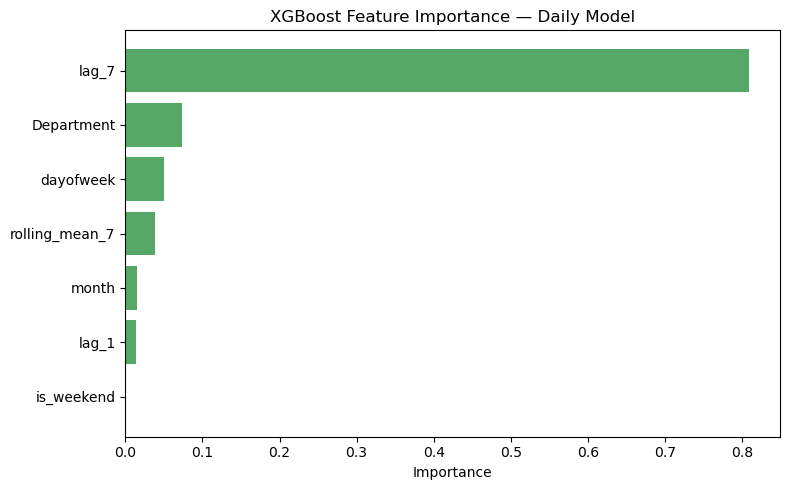

In [110]:
#feature importance for the XGBoost model
importance = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)  # ascending so barh reads top-to-bottom nicely

plt.figure(figsize=(8,5))
plt.barh(importance['feature'], importance['importance'], color='#55A868')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance — Daily Model')
plt.tight_layout()
plt.show()

## Observation

- lag_7 dominates (~80% of importance) - the visit count from the same day one week ago is by far the model's strongest predictor.
- Department and dayofweek are secondary (~5-7% each) - they add some signal, but far less than lag_7.
- rolling_mean_7, month, lag_1, and is_weekend contribute marginally - the model relies on them very little.
- Why lag_7 wins: it implicitly captures day-of-week pattern, department norms, and recent trend all in one number - so it makes the standalone dayofweek/is_weekend features partly redundant, even though your earlier chi-square and t-test proved those factors matter statistically on their own

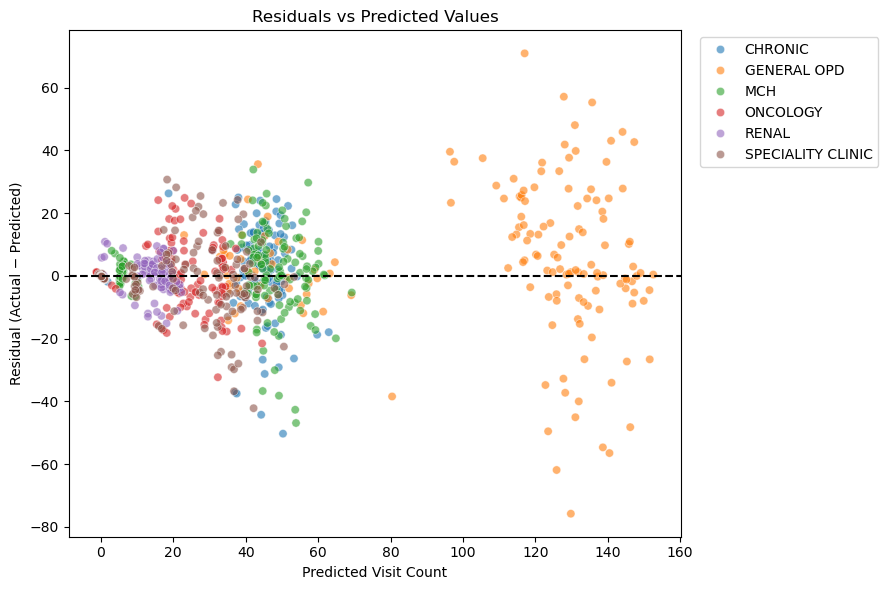

In [111]:
#residual vs predicted plot for the XGBoost model
test_long['residual'] = test_long['VisitCount'] - test_long['pred']

plt.figure(figsize=(9,6))
sns.scatterplot(data=test_long, x='pred', y='residual', hue='Department', alpha=0.6, palette='tab10')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Visit Count')
plt.ylabel('Residual (Actual − Predicted)')
plt.title('Residuals vs Predicted Values')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Observation

The plot splits into two clusters by department volume: low-volume departments (Chronic Care, MCH, Oncology, Renal, Speciality Clinic) sit tightly clustered on the left with residuals mostly within +-20, while General OPD sits separately on the right with a wider spread (-80 to +65). This wider spread doesn't mean General OPD is less reliable — it's a raw-error effect of its much larger baseline volume; proportionally (per MAPE), General OPD remains the model's most accurate department. Residuals are balanced above and below zero for every department, showing no systematic over- or under-prediction bias. A few General OPD outliers (beyond -60) likely reflect atypical days — holidays or unrecorded surges — that the model's lag_7-driven, calendar-based features couldn't anticipate.

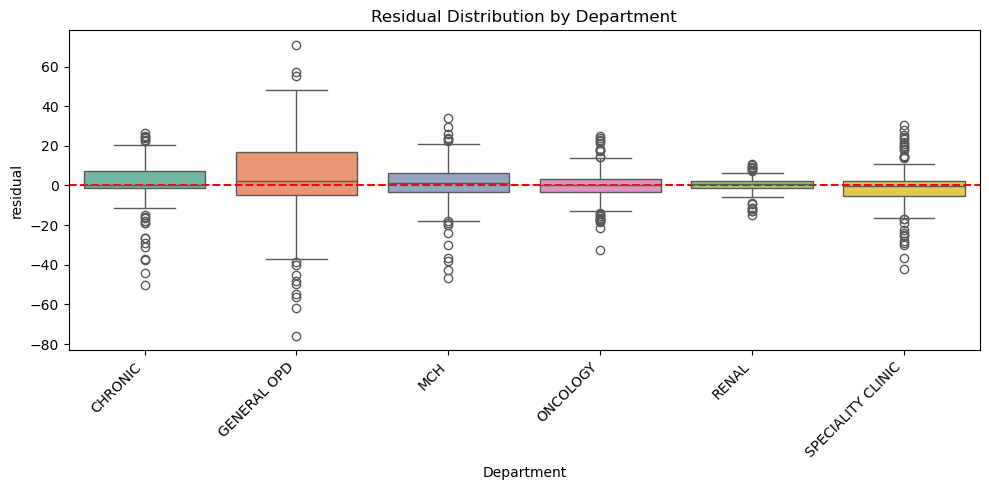

In [112]:
#Residual distribution by department for the XGBoostRegressor model
plt.figure(figsize=(10,5))
sns.boxplot(data=test_long, x='Department', y='residual', palette='Set2')
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title('Residual Distribution by Department')
plt.tight_layout()
plt.show()

## Observation

The residual boxplot confirms no systematic bias across any department - all six medians sit close to zero. General OPD shows the widest typical (box) spread in raw terms, consistent with its higher baseline volume rather than worse relative accuracy. The low-volume departments (MCH, Oncology, Renal, Speciality Clinic) show tight boxes but a dense band of outlier days just beyond their whiskers - indicating that although their raw errors are small, they fall outside the department's own "normal" range frequently, consistent with their higher MAPE scores. A handful of General OPD outliers extending to -75/+65 likely correspond to atypical days (e.g. holidays or unrecorded demand shocks) not captured by the model's calendar-based features.

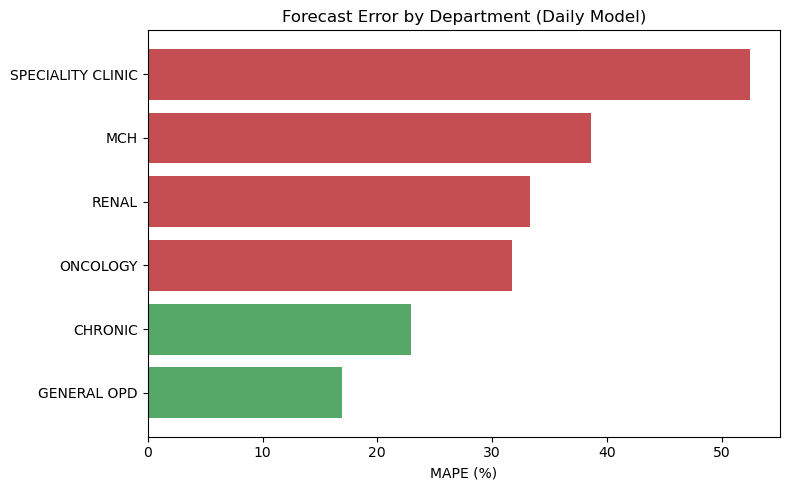

In [113]:
# MAPE daily distribution per department
mape_by_dept_sorted = mape_by_dept.sort_values()

plt.figure(figsize=(8,5))
colors = ['#C44E52' if v > 30 else '#55A868' for v in mape_by_dept_sorted.values]
plt.barh(mape_by_dept_sorted.index, mape_by_dept_sorted.values, color=colors)
plt.xlabel('MAPE (%)')
plt.title('Forecast Error by Department (Daily Model)')
plt.tight_layout()
plt.show()

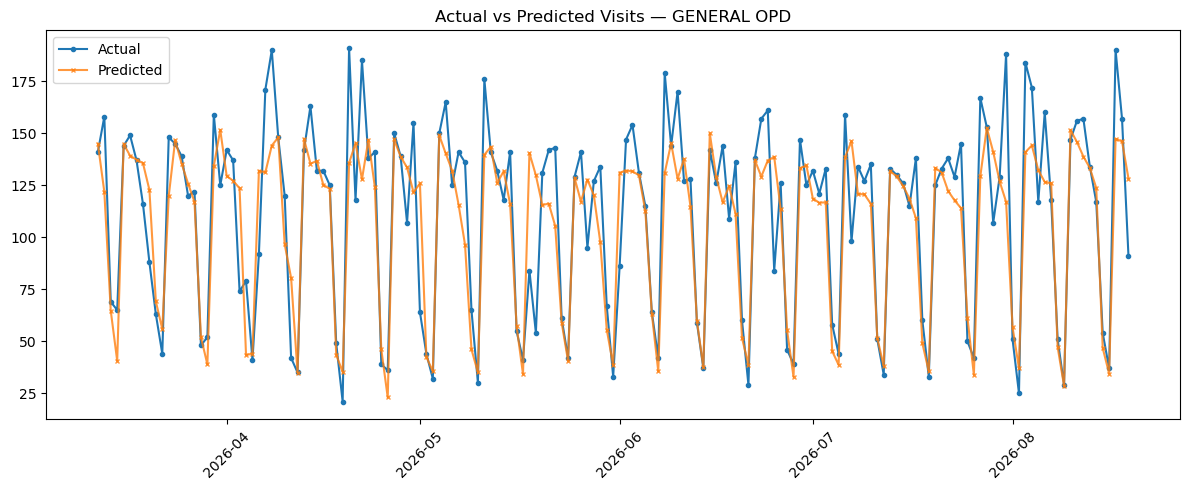

In [114]:
# Visualize the actual vs predicted visits for a specific department
dept_check = 'GENERAL OPD'
subset = test_long[test_long['Department'] == dept_check].sort_values('Date')

plt.figure(figsize=(12,5))
plt.plot(subset['Date'], subset['VisitCount'], label='Actual', marker='o', markersize=3)
plt.plot(subset['Date'], subset['pred'], label='Predicted', marker='x', markersize=3, alpha=0.8)
plt.legend()
plt.title(f'Actual vs Predicted Visits — {dept_check}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation

The actual-vs-predicted plot for General OPD shows the model successfully tracking the weekly demand rhythm, correctly anticipating both peak and quiet days in the right sequence. However, the model consistently underestimates the height of peak days, while closely matching the low/quiet days. This pattern is consistent with the model's heavy reliance on lag_7 (same day, one week prior): since actual volume shows a mild upward trend over time, "same as last week" tends to lag slightly behind true peak demand, explaining both the gap between RMSE and MAE and the small number of large negative outliers observed in the residual analysis.

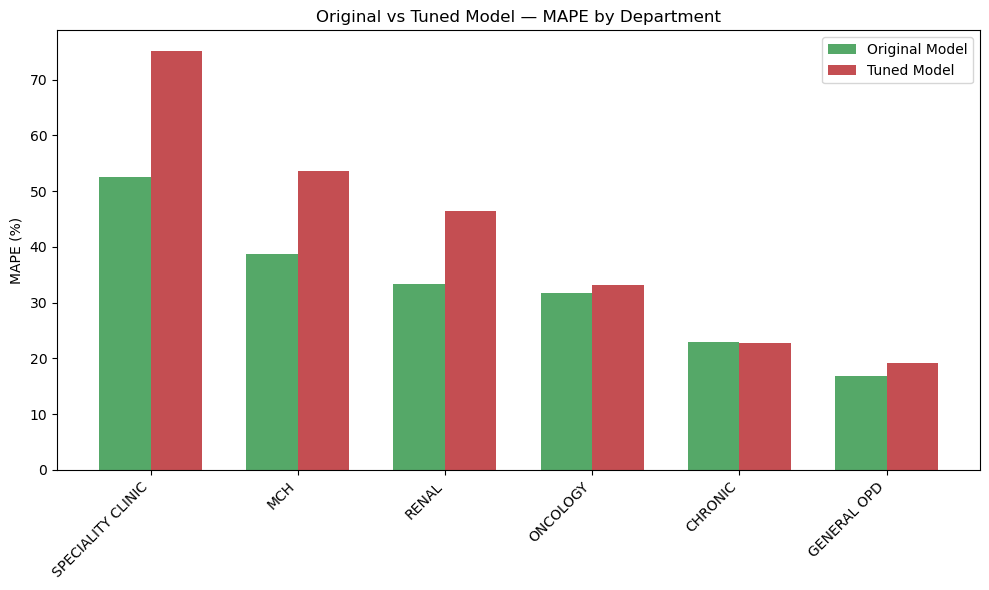

In [115]:
depts = mape_by_dept.index.tolist()
original_vals = [mape_by_dept[d] for d in depts]
tuned_vals = [tuned_mape_by_dept[d] for d in depts]

x = np.arange(len(depts))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, original_vals, width, label='Original Model', color='#55A868')
ax.bar(x + width/2, tuned_vals, width, label='Tuned Model', color='#C44E52')
ax.set_ylabel('MAPE (%)')
ax.set_title('Original vs Tuned Model — MAPE by Department')
ax.set_xticks(x)
ax.set_xticklabels(depts, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

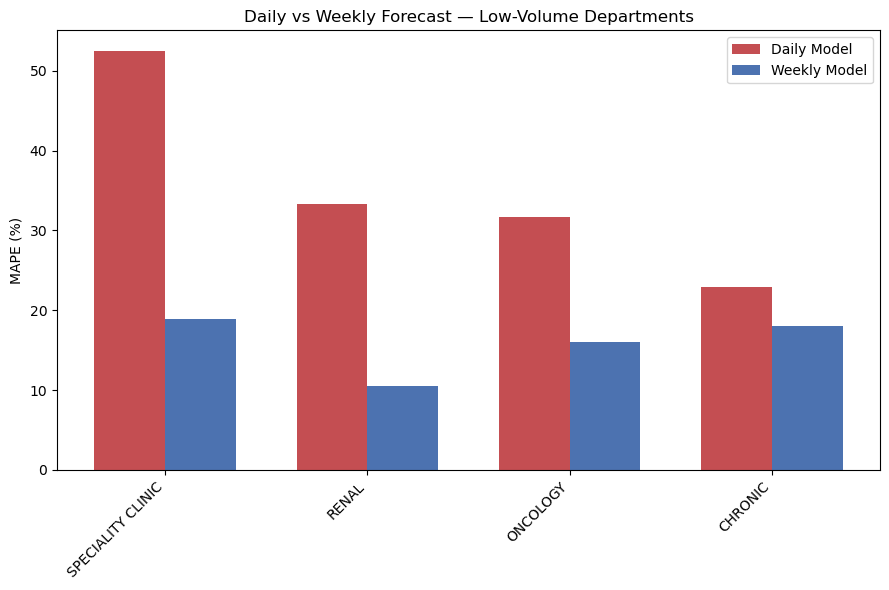

In [116]:
# Visualize the MAPE for the sparse departments, comparing daily vs weekly models
sparse_depts = ['SPECIALITY CLINIC', 'RENAL', 'ONCOLOGY', 'CHRONIC']
daily_vals = [mape_by_dept[d] for d in sparse_depts]
weekly_vals = [weekly_mape_by_dept[d] for d in sparse_depts]

x = np.arange(len(sparse_depts))
fig, ax = plt.subplots(figsize=(9,6))
ax.bar(x - width/2, daily_vals, width, label='Daily Model', color='#C44E52')
ax.bar(x + width/2, weekly_vals, width, label='Weekly Model', color='#4C72B0')
ax.set_ylabel('MAPE (%)')
ax.set_title('Daily vs Weekly Forecast — Low-Volume Departments')
ax.set_xticks(x)
ax.set_xticklabels(sparse_depts, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Observation
- Weekly beats daily for every low-volume department - no exceptions, all four show a clear drop in error.
- Speciality Clinic improves the most - roughly 50% daily error down to ~21% weekly.
- Renal ends up the most reliable — from ~34% down to ~11%, the best final result of the four.
- Chronic Care improves the least, but still improves - ~23% down to ~18%.
Bottom line: low-volume departments aren't unpredictable, they're just too noisy day-to-day — weekly aggregation smooths that out, validating the two-tier daily/weekly model setup.

## Survival Analysis

In [117]:
# !pip install lifelines

In [118]:
from lifelines import KaplanMeierFitter

In [119]:
# Sort by patient and date
df_survival = data_opd_only.sort_values(['PatientNumber', 'RegistrationDate']).copy()

#  Find each patient's next visit date (forward-looking question, not backward)
df_survival['NextVisitDate'] = df_survival.groupby('PatientNumber')['RegistrationDate'].shift(-1)

#  Event = 1 if a next visit exists, 0 if this is their last known visit (censored)
df_survival['returned'] = df_survival['NextVisitDate'].notna().astype(int)

# Duration: 
#    if they returned, it's the real gap until their next visit
#    if they didn't (censored), it's the time from this visit to the end of the dataset 
data_end_date = data_opd_only['RegistrationDate'].max()

df_survival['duration'] = np.where(
    df_survival['returned'] == 1,
    (df_survival['NextVisitDate'] - df_survival['RegistrationDate']).dt.days,
    (data_end_date - df_survival['RegistrationDate']).dt.days
)

print(df_survival.shape)
df_survival[['PatientNumber','RegistrationDate','NextVisitDate','duration','returned']].head()

(265285, 18)


,PatientNumber,RegistrationDate,NextVisitDate,duration,returned
201077,010462209,2025-12-01 11:14:18.020,2025-12-19 11:58:16.467,18.0,1
208542,010462209,2025-12-19 11:58:16.467,2025-12-29 15:30:32.610,10.0,1
210387,010462209,2025-12-29 15:30:32.610,2026-08-11 11:47:19.917,224.0,1
302623,010462209,2026-08-11 11:47:19.917,NaT,7.0,0
29446,010000979,2024-08-23 08:19:39.000,NaT,726.0,0


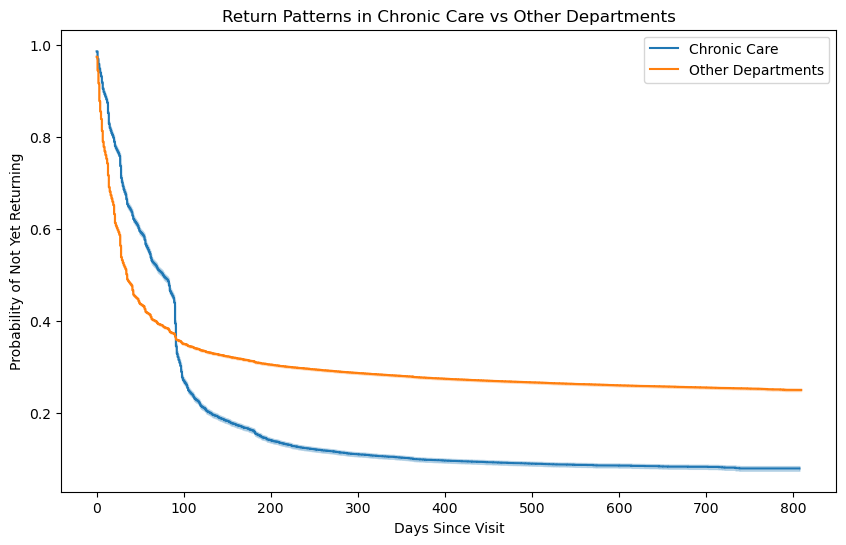

In [120]:
# Chronic care compared to other departments
chronic_label = data_opd_only[data_opd_only['QueuedTo_Grouped'].str.contains('CHRONIC', na=False)]['QueuedTo_Grouped'].unique()[0]
chronic_mask = df_survival['QueuedTo_Grouped'] == chronic_label

kmf_chronic = KaplanMeierFitter()
kmf_chronic.fit(
    durations = df_survival[chronic_mask]['duration'],
    event_observed = df_survival[chronic_mask]['returned'],
    label = 'Chronic Care'
)

kmf_other = KaplanMeierFitter()
kmf_other.fit(
    durations = df_survival[~chronic_mask]['duration'],
    event_observed = df_survival[~chronic_mask]['returned'],
    label = 'Other Departments'
)

fig, ax = plt.subplots(figsize=(10,6))
kmf_chronic.plot_survival_function(ax=ax)
kmf_other.plot_survival_function(ax=ax)
plt.title('Return Patterns in Chronic Care vs Other Departments')
plt.xlabel('Days Since Visit')
plt.ylabel('Probability of Not Yet Returning')
plt.show()

# a lower survival curve shows more frequent return

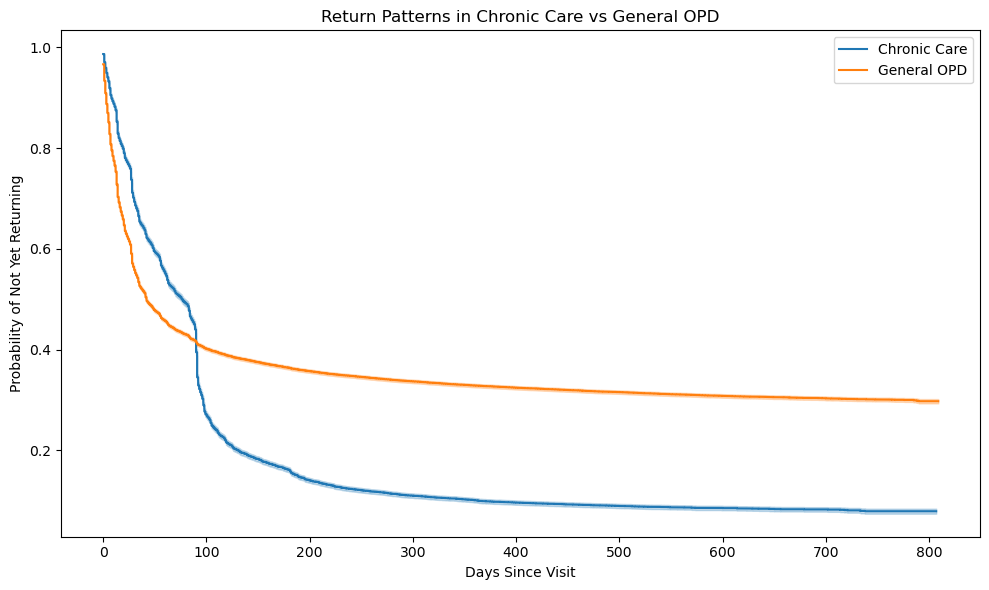

In [121]:
# General OPD against Chronic care
general_mask = df_survival['QueuedTo_Grouped'] == 'GENERAL OPD'

kmf_general = KaplanMeierFitter()
kmf_general.fit(
    durations = df_survival[general_mask]['duration'],
    event_observed = df_survival[general_mask]['returned'],
    label = 'General OPD'
)

fig, ax = plt.subplots(figsize=(10,6))
kmf_chronic.plot_survival_function(ax=ax)
kmf_general.plot_survival_function(ax=ax)
plt.title('Return Patterns in Chronic Care vs General OPD')
plt.xlabel('Days Since Visit')
plt.ylabel('Probability of Not Yet Returning')
plt.tight_layout()
plt.show()

# Observation
The Kaplan-Meier curves indicate differences in time-to-return between Chronic Care and General OPD patients. A lower survival probability for Chronic Care indicates that these patients tend to return sooner or more frequently during follow-up.

# RENAL DEPT ANALYSIS

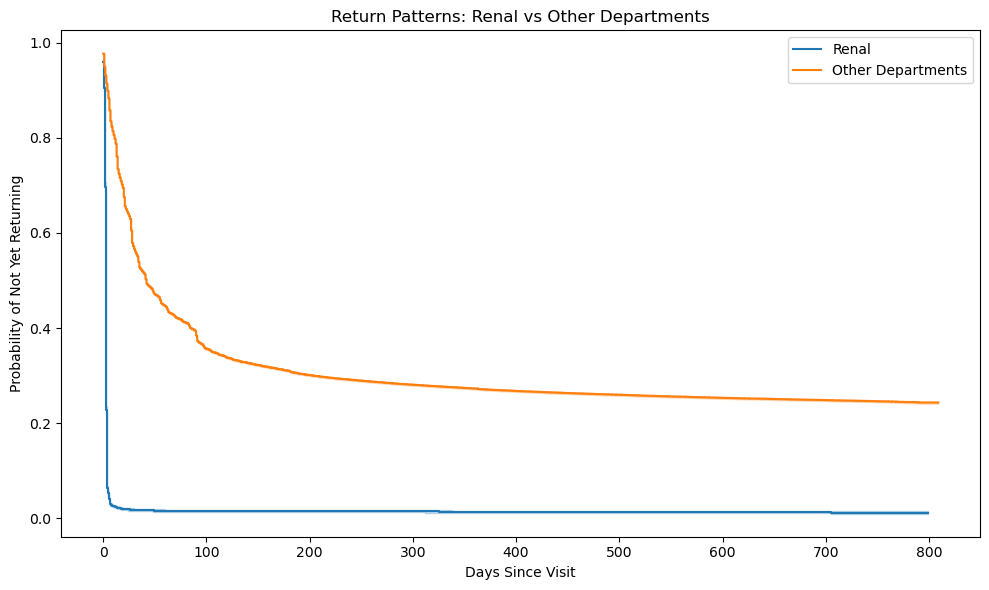

In [122]:
# Renal vs every other department
renal_label = data_opd_only[data_opd_only['QueuedTo_Grouped'].str.contains('RENAL', na=False)]['QueuedTo_Grouped'].unique()[0]
renal_mask = df_survival['QueuedTo_Grouped'] == renal_label

kmf_renal = KaplanMeierFitter()
kmf_renal.fit(
    durations = df_survival[renal_mask]['duration'],
    event_observed = df_survival[renal_mask]['returned'],
    label = 'Renal'
)

kmf_other = KaplanMeierFitter()
kmf_other.fit(
    durations = df_survival[~renal_mask]['duration'],
    event_observed = df_survival[~renal_mask]['returned'],
    label = 'Other Departments'
)

fig, ax = plt.subplots(figsize=(10,6))
kmf_renal.plot_survival_function(ax=ax)
kmf_other.plot_survival_function(ax=ax)
plt.title('Return Patterns: Renal vs Other Departments')
plt.xlabel('Days Since Visit')
plt.ylabel('Probability of Not Yet Returning')
plt.tight_layout()
plt.show()

# A LOWER curve = faster/more frequent return.

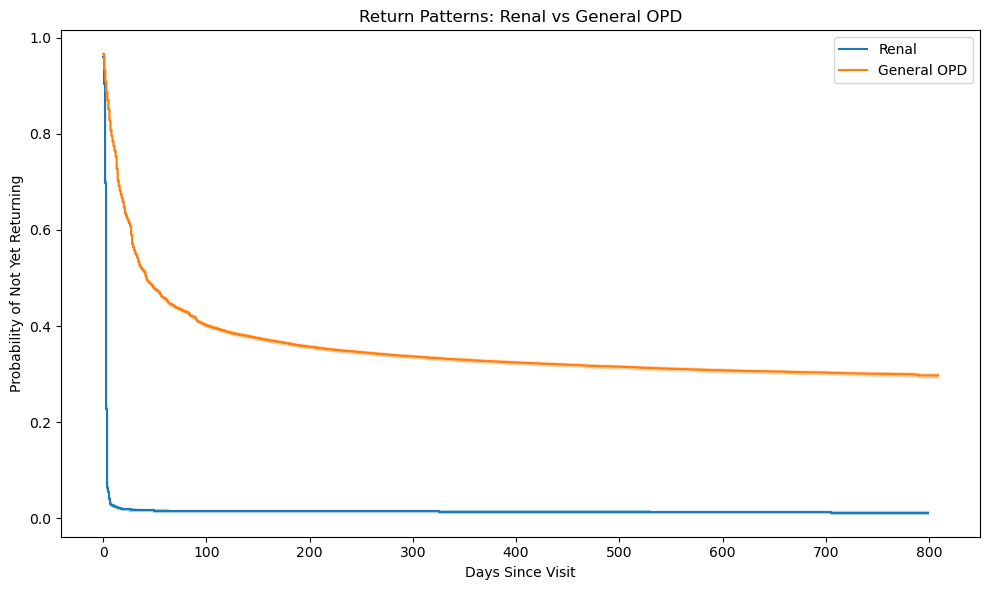

In [123]:
# General OPD vs Renal
general_mask = df_survival['QueuedTo_Grouped'] == 'GENERAL OPD'

kmf_general = KaplanMeierFitter()
kmf_general.fit(
    durations=df_survival[general_mask]['duration'],
    event_observed=df_survival[general_mask]['returned'],
    label='General OPD'
)

fig, ax = plt.subplots(figsize=(10,6))
kmf_renal.plot_survival_function(ax=ax)
kmf_general.plot_survival_function(ax=ax)
plt.title('Return Patterns: Renal vs General OPD')
plt.xlabel('Days Since Visit')
plt.ylabel('Probability of Not Yet Returning')
plt.tight_layout()
plt.show()

# Observation

Renal department has a sharp drop when compared to general OPD and other top departments. This indicates a faster rate of return

# Log Rank Test for survival analysis

In [124]:
from lifelines.statistics import logrank_test

### What do we want to answer? 
- Are the survival/time-to-return distributions significantly different between the groups?

In [125]:
# Log-rank tests: is the difference between curves statistically significant, or could it be chance?
# Log rank test for chronic care vs Other departments;

result_chronic_other = logrank_test(
    df_survival[chronic_mask]['duration'], df_survival[~chronic_mask]['duration'],
    event_observed_A=df_survival[chronic_mask]['returned'],
    event_observed_B=df_survival[~chronic_mask]['returned']
)
print("Chronic Care vs Other Departments")
print(f"test statistic = {result_chronic_other.test_statistic:.2f}, p-value = {result_chronic_other.p_value:.2e}")
print()

# Log rank test - chronic care vs General OPD
result_chronic_general = logrank_test(
    df_survival[chronic_mask]['duration'], df_survival[general_mask]['duration'],
    event_observed_A=df_survival[chronic_mask]['returned'],
    event_observed_B=df_survival[general_mask]['returned']
)
print("Chronic Care vs General OPD")
print(f"test statistic = {result_chronic_general.test_statistic:.2f}, p-value = {result_chronic_general.p_value:.2e}")
print()

# Log rank test - renal dept vs General OPD
result_renal_general = logrank_test(
    df_survival[renal_mask]['duration'], df_survival[general_mask]['duration'],
    event_observed_A=df_survival[renal_mask]['returned'],
    event_observed_B=df_survival[general_mask]['returned']
)
print("Renal vs General OPD")
print(f"test statistic = {result_renal_general.test_statistic:.2f}, p-value = {result_renal_general.p_value:.2e}")

Chronic Care vs Other Departments
test statistic = 80.99, p-value = 2.27e-19

Chronic Care vs General OPD
test statistic = 664.06, p-value = 1.96e-146

Renal vs General OPD
test statistic = 39408.16, p-value = 0.00e+00


In [132]:
print(df_survival['QueuedTo_Grouped'].dtype)
print(df_survival.groupby('QueuedTo_Grouped', observed=True)['duration'].count())

object
QueuedTo_Grouped
CHRONIC              25365
GENERAL OPD          85620
MCH                  29451
ONCOLOGY             13606
RENAL                11103
SPECIALITY CLINIC    22356
Name: duration, dtype: int64


# Cox Regression - Cox Proportional Hazards Model

- How does the department, age, gender etc affect the rate of patient return?
- Which patient/department characteristics are associated with a higher or lower rate of returning to the hospital, after accounting for the time each patient is observed?

In [133]:
# !pip install lifelines
from lifelines import CoxPHFitter

In [134]:
# Check the variables we will use
df_survival[['PatientNumber', 'RegistrationDate', 'QueuedTo_Grouped',
     'AgeYears', 'Gender', 'duration', 'returned']].head()

,PatientNumber,RegistrationDate,QueuedTo_Grouped,AgeYears,Gender,duration,returned
201077,010462209,2025-12-01 11:14:18.020,MCH,34.0,FEMALE,18.0,1
208542,010462209,2025-12-19 11:58:16.467,MCH,34.0,FEMALE,10.0,1
210387,010462209,2025-12-29 15:30:32.610,MCH,34.0,FEMALE,224.0,1
302623,010462209,2026-08-11 11:47:19.917,NaN,34.0,FEMALE,7.0,0
29446,010000979,2024-08-23 08:19:39.000,ONCOLOGY,45.0,FEMALE,726.0,0


In [135]:
# Keep only observations with valid survival information
cox_data = df_survival[['duration', 'returned', 'QueuedTo_Grouped', 'AgeYears', 'Gender']].copy()

# Remove missing values in variables used by the Cox model
cox_data = cox_data.dropna()

# Make sure duration is positive
cox_data = cox_data[cox_data['duration'] > 0]

print("Records for Cox regression:", len(cox_data))
cox_data.head()

Records for Cox regression: 182353


,duration,returned,QueuedTo_Grouped,AgeYears,Gender
201077,18.0,1,MCH,34.0,FEMALE
208542,10.0,1,MCH,34.0,FEMALE
210387,224.0,1,MCH,34.0,FEMALE
29446,726.0,0,ONCOLOGY,45.0,FEMALE
9528,28.0,1,MCH,40.0,FEMALE


In [136]:
# Convert categorical variables into numerical dummy variables
cox_data = pd.get_dummies(cox_data,columns=['QueuedTo_Grouped', 'Gender'],
                          drop_first=True, dtype=int)

cox_data.head()

,duration,returned,AgeYears,QueuedTo_Grouped_GENERAL OPD,QueuedTo_Grouped_MCH,QueuedTo_Grouped_ONCOLOGY,QueuedTo_Grouped_RENAL,QueuedTo_Grouped_SPECIALITY CLINIC,Gender_MALE
201077,18.0,1,34.0,0,1,0,0,0,0
208542,10.0,1,34.0,0,1,0,0,0,0
210387,224.0,1,34.0,0,1,0,0,0,0
29446,726.0,0,45.0,0,0,1,0,0,0
9528,28.0,1,40.0,0,1,0,0,0,0


In [137]:
# Create the Cox proportional hazards model
# Instantiate
cph = CoxPHFitter(penalizer = 0.1)

# Fit the model
cph.fit(cox_data,duration_col='duration', event_col='returned')

# Display the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 182353 total observations, 51750 right-censored observations>
             duration col = 'duration'
                event col = 'returned'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 182353
number of events observed = 130603
   partial log-likelihood = -1489899.56
         time fit was run = 2026-09-16 19:17:25 UTC

---
                                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                           
AgeYears                            0.00      1.00      0.00            0.00            0.00                1.00                1.00
QueuedTo_Grouped_GENERAL OPD       -0.24      0.79      0.01           -0.25           -0.23                0.78                0.80
QueuedTo_Grouped_MCH               -0.02      0.98      0.01           -0.04           -0.00                0.96                1.00
QueuedTo_Grouped_ONCOLOGY           0.49      1.64      0.01            0.47            0.51                1.61                1.67
QueuedTo_Grouped_RENAL              2.09      8.07      0.01            2.06            2.11                7.88                8.27
QueuedTo_Grouped_SPECIALITY CLINIC -0.21      0.81      0.01           -0.22           -0.19                0.80                0.83
Gender_MALE                        -0.03      0.97      0.01           -0.04           -0.02                0.96                0.98

                                    cmp to      z      p  -log2(p)
covariate                                                         
AgeYears                              0.00  30.44 <0.005    673.83
QueuedTo_Grouped_GENERAL OPD          0.00 -35.86 <0.005    933.18
QueuedTo_Grouped_MCH                  0.00  -2.14   0.03      4.93
QueuedTo_Grouped_ONCOLOGY             0.00  47.54 <0.005       inf
QueuedTo_Grouped_RENAL                0.00 168.63 <0.005       inf
QueuedTo_Grouped_SPECIALITY CLINIC    0.00 -22.78 <0.005    379.14
Gender_MALE                           0.00  -5.37 <0.005     23.56
---
Concordance = 0.59
Partial AIC = 2979813.13
log-likelihood ratio test = 31637.35 on 7 df
-log2(p) of ll-ratio test = inf

In [138]:
# Present the results clearly in a summary table

cox_results = pd.DataFrame({
    'Hazard_Ratio': np.exp(cph.params_),
    'Lower_95_CI': np.exp(cph.confidence_intervals_['95% lower-bound']),
    'Upper_95_CI': np.exp(cph.confidence_intervals_['95% upper-bound']),
    'P_value': cph.summary['p']
}).round({'Hazard_Ratio':3, 'Lower_95_CI':3, 'Upper_95_CI':3, 'P_value':4})

cox_results = cox_results.round(3)

print(cox_results)

                                    Hazard_Ratio  Lower_95_CI  Upper_95_CI  \
covariate                                                                    
AgeYears                                   1.004        1.004        1.004   
QueuedTo_Grouped_GENERAL OPD               0.787        0.777        0.798   
QueuedTo_Grouped_MCH                       0.981        0.964        0.998   
QueuedTo_Grouped_ONCOLOGY                  1.639        1.606        1.672   
QueuedTo_Grouped_RENAL                     8.075        7.881        8.273   
QueuedTo_Grouped_SPECIALITY CLINIC         0.814        0.800        0.829   
Gender_MALE                                0.972        0.962        0.982   

                                    P_value  
covariate                                    
AgeYears                              0.000  
QueuedTo_Grouped_GENERAL OPD          0.000  
QueuedTo_Grouped_MCH                  0.033  
QueuedTo_Grouped_ONCOLOGY             0.000  
QueuedTo_Grouped_RENA

In [139]:
# what is the percentage difference with the reference department

cox_results['Percent_Change'] = (
    (cox_results['Hazard_Ratio'] - 1) * 100
).round(1)

print(cox_results)

                                    Hazard_Ratio  Lower_95_CI  Upper_95_CI  \
covariate                                                                    
AgeYears                                   1.004        1.004        1.004   
QueuedTo_Grouped_GENERAL OPD               0.787        0.777        0.798   
QueuedTo_Grouped_MCH                       0.981        0.964        0.998   
QueuedTo_Grouped_ONCOLOGY                  1.639        1.606        1.672   
QueuedTo_Grouped_RENAL                     8.075        7.881        8.273   
QueuedTo_Grouped_SPECIALITY CLINIC         0.814        0.800        0.829   
Gender_MALE                                0.972        0.962        0.982   

                                    P_value  Percent_Change  
covariate                                                    
AgeYears                              0.000             0.4  
QueuedTo_Grouped_GENERAL OPD          0.000           -21.3  
QueuedTo_Grouped_MCH                  0.033      

# Observation 

- The column we are interested in is exp(coef). Therefore, if HR > 1, it suggests higher rate of returning. HR < 1 lower rate of returning, and HR = 1 shows no difference in return rate. 
- The Renal department for instance, had the largest estimated association with the rate of subsequent OPD return (HR = 8.69, p < 0.001), indicating an estimated 769% higher return rate compared with the reference department, after adjusting for age and gender. On the other hand, there is essentially no evidence that MCH differs from the reference departments in return rate after adjustment

In [140]:
# Extract the main Cox regression results
cox_results = pd.DataFrame({
    'Hazard_Ratio': np.exp(cph.params_),
    'Lower_95_CI': np.exp(cph.confidence_intervals_['95% lower-bound']),
    'Upper_95_CI': np.exp(cph.confidence_intervals_['95% upper-bound']),
    'P_value': cph.summary['p']})

# Round for uniformity with the rest of the notebook 
cox_results = cox_results.round({
    'Hazard_Ratio': 3,
    'Lower_95_CI': 3,
    'Upper_95_CI': 3,
    'P_value': 4})

cox_results

,Hazard_Ratio,Lower_95_CI,Upper_95_CI,P_value
covariate,,,,
AgeYears,1.004,1.004,1.004,0.0000
QueuedTo_Grouped_GENERAL OPD,0.787,0.777,0.798,0.0000
QueuedTo_Grouped_MCH,0.981,0.964,0.998,0.0327
QueuedTo_Grouped_ONCOLOGY,1.639,1.606,1.672,0.0000
QueuedTo_Grouped_RENAL,8.075,7.881,8.273,0.0000
QueuedTo_Grouped_SPECIALITY CLINIC,0.814,0.800,0.829,0.0000
Gender_MALE,0.972,0.962,0.982,0.0000


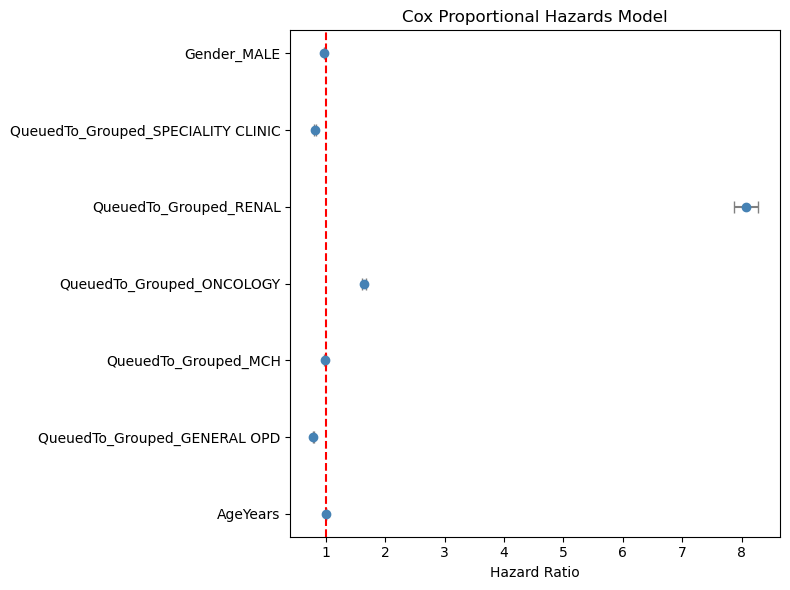

In [141]:
# Get hazard ratios and confidence intervals
hr = np.exp(cph.params_)
ci = np.exp(cph.confidence_intervals_)

# Create the plot
plt.figure(figsize=(8, 6))

y_positions = np.arange(len(hr))

plt.errorbar(
    hr,
    y_positions,
    xerr=[
        hr - ci['95% lower-bound'],
        ci['95% upper-bound'] - hr
    ],
    fmt='o',
    color='steelblue',
    ecolor='gray',
    capsize=4
)
# Reference line: HR = 1
plt.axvline(1, color='red', linestyle='--')

plt.yticks(y_positions, hr.index)
plt.xlabel('Hazard Ratio')
plt.title('Cox Proportional Hazards Model')
plt.tight_layout()
plt.show()


In [142]:
print(hr)
print(ci)

covariate
AgeYears                              1.003754
QueuedTo_Grouped_GENERAL OPD          0.787286
QueuedTo_Grouped_MCH                  0.981016
QueuedTo_Grouped_ONCOLOGY             1.638588
QueuedTo_Grouped_RENAL                8.074737
QueuedTo_Grouped_SPECIALITY CLINIC    0.814499
Gender_MALE                           0.971758
Name: coef, dtype: float64
                                    95% lower-bound  95% upper-bound
covariate                                                           
AgeYears                                   1.003512         1.003997
QueuedTo_Grouped_GENERAL OPD               0.777062         0.797644
QueuedTo_Grouped_MCH                       0.963912         0.998424
QueuedTo_Grouped_ONCOLOGY                  1.605561         1.672294
QueuedTo_Grouped_RENAL                     7.881071         8.273162
QueuedTo_Grouped_SPECIALITY CLINIC         0.800246         0.829006
Gender_MALE                                0.961641         0.981981
